# Python CRM Leads Mini Project

# Lead Pipeline Analysis — Nexus Digital

## Project Objective
The goal of this project is to analyze Nexus Digital's 2024 lead pipeline data in order to identify bottlenecks in the sales funnel, evaluate channel performance, and generate actionable business recommendations.

The analysis focuses on lead conversion, acquisition efficiency, sales performance, and revenue-related KPIs.

## Environment Setup

This section imports all required Python libraries for data analysis and visualization.

The notebook configuration is also adjusted to improve readability by displaying all columns, formatting numeric outputs, and applying consistent visualization styling.

In [42]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

# pandas is the main library for data manipulation and analysis
import pandas as pd

# numpy provides mathematical and numerical tools
import numpy as np

# matplotlib is used for creating basic visualizations
import matplotlib.pyplot as plt

# seaborn builds on matplotlib and creates cleaner statistical charts
import seaborn as sns

# warnings helps suppress unnecessary warning messages
import warnings


# =========================================================
# NOTEBOOK CONFIGURATION
# =========================================================

# Hide warning messages to keep notebook output clean and readable
warnings.filterwarnings("ignore")

# Show all columns when displaying DataFrames
pd.set_option("display.max_columns", None)

# Allow more rows to be displayed before truncation
pd.set_option("display.max_rows", 100)

# Format floating-point numbers to 2 decimal places
pd.set_option("display.float_format", "{:,.2f}".format)


# =========================================================
# VISUALIZATION SETTINGS
# =========================================================

# Apply a clean default style for charts
sns.set_style("whitegrid")

# Set default chart size
plt.rcParams["figure.figsize"] = (10, 6)

## Load Dataset

In this section, we load the CRM dataset into a pandas DataFrame and verify that the file was imported successfully.

In [43]:
# =========================================================
# LOAD DATASET
# =========================================================

# Load the CSV file into a pandas DataFrame
# parse_dates automatically converts date columns into datetime format
df = pd.read_csv(
    "leads_data.csv",
    parse_dates=["created_date", "last_activity_date"]
)

# Display the first 5 rows to verify successful loading
df.head()

,lead_id,first_name,last_name,email,company_name,industry,company_size,lead_source,campaign_name,lead_score,status,assigned_rep,created_date,last_activity_date,days_to_first_contact,deal_value,lost_reason
0,1,Matthew,Scott,matthew.scott@ultracoresystems.com,UltraCore Systems,Technology,Large (201-1000),Google Ads,GoogQ3_Retargeting,34,Proposal,Emily Rodriguez,08/04/2024,2024-04-21,8,63600,NaN
1,2,Susan,Long,susan.long@peakperformanceco.com,PeakPerformance Co,Technology,Medium (51-200),Cold Email,ColdEmail_Vertical_Blast,53,Proposal,James Morrison,11/05/2024,2024-06-28,20,13900,NaN
2,3,Emily,Torres,emily.torres@optiflow.com,OptiFlow,Technology,Large (201-1000),Cold Email,ColdEmail_Re_Engagement,74,Qualified,Sarah Chen,07/05/2024,2024-06-05,15,43800,NaN
3,4,Emily,Wright,emily.wright@novacrestcapital.com,NovaCrest Capital,Finance,Small (1-50),Referral,Referral_Employee,100,Proposal,James Morrison,22/09/2024,2024-12-21,8,6400,NaN
4,5,Benjamin,Sanders,benjamin.sanders@yieldmaxcorp.com,YieldMax Corp,Healthcare,Enterprise (1000+),Cold Email,ColdEmail_Series_A,46,Lost,Emily Rodriguez,05/04/2024,2024-04-23,8,72000,Competitor


## Initial Data Inspection

In this section, we examine the overall structure of the dataset, including its size, column types, and completeness.

This helps us identify potential data quality issues before moving into deeper analysis.

In [44]:
# =========================================================
# INITIAL DATA INSPECTION
# =========================================================

# Get the number of rows and columns in the dataset
# shape returns a tuple in the form: (rows, columns)
rows, columns = df.shape

# Print dataset dimensions in a readable format
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

# Display DataFrame structure:
# - column names
# - data types
# - non-null counts (helps identify missing values)
df.info()

Number of rows: 600
Number of columns: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   lead_id                600 non-null    int64         
 1   first_name             600 non-null    object        
 2   last_name              600 non-null    object        
 3   email                  600 non-null    object        
 4   company_name           600 non-null    object        
 5   industry               600 non-null    object        
 6   company_size           600 non-null    object        
 7   lead_source            600 non-null    object        
 8   campaign_name          600 non-null    object        
 9   lead_score             600 non-null    int64         
 10  status                 600 non-null    object        
 11  assigned_rep           600 non-null    object        
 12  created_date          

## Initial Data Inspection Findings

- The dataset contains **600 rows** and **17 columns**
- Most columns are fully populated with no missing values
- The dataset includes **12 categorical columns**, **4 numerical columns**, and **1 datetime column**
- The `lost_reason` column contains missing values, which is expected because only lost leads should have a loss reason
- The `created_date` column was not automatically parsed as a datetime object and may require additional cleaning

## Statistical Summary

In this section, we generate descriptive statistics for both numerical and categorical variables.

This helps us understand data distributions, central tendencies, variability, and the most common categorical values in the dataset.

In [45]:
df.describe(include="all")

,lead_id,first_name,last_name,email,company_name,industry,company_size,lead_source,campaign_name,lead_score,status,assigned_rep,created_date,last_activity_date,days_to_first_contact,deal_value,lost_reason
count,600.00,600,600,600,600,600,600,600,600,600.00,600,600,600,600,600.00,600.00,143
unique,NaN,78,99,600,104,7,4,8,31,NaN,7,6,292,NaN,NaN,NaN,5
top,NaN,Raymond,Russell,matthew.scott@ultracoresystems.com,VoltaLabs,Technology,Medium (51-200),Google Ads,LI_Tech_Leaders,NaN,Lost,Marcus Webb,05/03/2024,NaN,NaN,NaN,No Response
freq,NaN,14,14,1,12,161,211,108,34,NaN,143,116,7,NaN,NaN,NaN,44
mean,300.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.59,NaN,NaN,NaN,2024-08-27 01:19:12,20.09,"55,944.17",NaN
min,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,NaN,NaN,NaN,2024-01-12 00:00:00,1.00,"2,000.00",NaN
25%,150.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.75,NaN,NaN,NaN,2024-05-30 00:00:00,7.00,"11,400.00",NaN
50%,300.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.00,NaN,NaN,NaN,2024-09-01 12:00:00,15.50,"27,400.00",NaN
75%,450.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.00,NaN,NaN,NaN,2024-11-21 00:00:00,30.00,"69,750.00",NaN
max,600.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.00,NaN,NaN,NaN,2025-03-15 00:00:00,97.00,"706,800.00",NaN


## Statistical Summary Findings

- The dataset contains **600 lead records** with complete numerical coverage for key business metrics such as **lead score**, **deal value**, and **response time**
- The most common industry is **Technology**, accounting for **161 leads**
- The most common company size is **Medium (51–200 employees)** with **211 leads**
- The most common acquisition channel is **Google Ads**, generating **108 leads**
- The most common lead status is **Lost**, with **143 leads**
- The average lead score is **52.59 / 100**, indicating moderate overall lead quality
- Lead scores range from **5 to 100**, showing wide variability in lead quality
- The average deal value is **$55,944**, with deals ranging from **$2,000 to $706,800**

## Missing Values Analysis

In this section, we examine missing values across all columns in order to identify potential data quality issues or business-driven null patterns.

Understanding missing values helps distinguish between actual data quality problems and expected missing information.

In [46]:
# =========================================================
# MISSING VALUES ANALYSIS
# =========================================================

# Count how many missing (null) values exist in each column
# isnull() returns True for missing values
# sum() counts how many True values appear in each column
missing_values = df.isnull().sum()

# Display missing values for every column
missing_values

lead_id                    0
first_name                 0
last_name                  0
email                      0
company_name               0
industry                   0
company_size               0
lead_source                0
campaign_name              0
lead_score                 0
status                     0
assigned_rep               0
created_date               0
last_activity_date         0
days_to_first_contact      0
deal_value                 0
lost_reason              457
dtype: int64

## Missing Values Findings

- All columns except one contain **no missing values**
- The only column with missing data is **`lost_reason`**, containing **457 missing values**
- Since only **143 leads** are currently marked as lost, missing values in `lost_reason` are expected and do **not necessarily indicate poor data quality**

This suggests that the dataset is highly complete and generally reliable for analysis.

## Categorical Variables Overview

In this section, we examine the categorical variables in the dataset and count how many unique values each variable contains.

This helps us understand the structure of business-related categories such as industries, acquisition channels, funnel stages, and sales representatives.

In [47]:
# =========================================================
# CATEGORICAL VARIABLES OVERVIEW
# =========================================================

# Select only columns with object data type
# These columns usually represent text or categorical variables
categorical_columns = df.select_dtypes(include="object")

# Count how many unique values exist in each categorical column
# nunique() counts distinct values in every selected column
unique_counts = categorical_columns.nunique()

# Display the number of unique categories per column
unique_counts

first_name        78
last_name         99
email            600
company_name     104
industry           7
company_size       4
lead_source        8
campaign_name     31
status             7
assigned_rep       6
created_date     292
lost_reason        5
dtype: int64

## Categorical Variables Findings

- The dataset contains **7 industries**, representing different business sectors
- There are **8 lead acquisition channels**, indicating multiple marketing sources
- The sales funnel contains **7 distinct lead statuses**
- Leads are managed by **6 sales representatives**
- There are **31 unique campaigns**, suggesting relatively diverse marketing activity
- The `lost_reason` column contains **5 distinct loss reasons**

# Initial EDA Summary

The exploratory data analysis indicates that the dataset is highly complete and suitable for business analysis.

Key findings from the initial exploration:

- The dataset contains **600 lead records** and **17 features**
- Most variables are complete, with no major missing data issues
- The only missing values appear in **`lost_reason`**, which aligns with expected business logic
- The dataset includes a mix of **numerical**, **categorical**, and **date-related** features
- There are **8 acquisition channels**, **7 industries**, **31 campaigns**, and **6 sales representatives**
- The average lead score is **52.59 / 100**, indicating moderate overall lead quality
- The `created_date` column may require additional preprocessing later due to formatting inconsistencies

Overall, the dataset appears reliable and provides a strong foundation for funnel, channel, and performance analysis.

# Part 1 — Sales Funnel Analysis

## Funnel Stage Distribution

In this section, we examine how leads are distributed across the different stages of the sales funnel.

This helps identify where leads are concentrated and provides an initial view of potential bottlenecks in the pipeline.

In [48]:
# =========================================================
# FUNNEL STAGE DISTRIBUTION
# =========================================================

# Count how many leads exist in each funnel stage
# value_counts() counts how many times each status appears
status_distribution = df["status"].value_counts()

# Display the raw funnel distribution
status_distribution

status
Lost           143
Contacted      138
Qualified      119
Proposal        73
Negotiation     51
New             40
Won             36
Name: count, dtype: int64

## Ordered Funnel View

The default output sorts funnel stages by frequency, which does not reflect the actual business progression of leads.

To better analyze the sales pipeline, we reorder the funnel stages according to the logical lead journey.

In [49]:
# =========================================================
# ORDER FUNNEL STAGES BY BUSINESS LOGIC
# =========================================================

# Define the logical order of stages in the sales funnel
# This represents the typical journey of a lead
funnel_order = [
    "New",
    "Contacted",
    "Qualified",
    "Proposal",
    "Negotiation",
    "Won",
    "Lost"
]

# Reorder the status distribution using the business-defined funnel order
# reindex() rearranges the index according to the list above
ordered_funnel = status_distribution.reindex(funnel_order)

# Display the ordered funnel distribution
ordered_funnel

status
New             40
Contacted      138
Qualified      119
Proposal        73
Negotiation     51
Won             36
Lost           143
Name: count, dtype: int64

## Funnel Stage Percentage Distribution

Absolute counts provide volume information, but percentages help evaluate the relative concentration of leads across funnel stages.

This allows us to better assess where the largest portions of leads are currently located within the sales pipeline.

In [50]:
# =========================================================
# FUNNEL STAGE PERCENTAGE DISTRIBUTION
# =========================================================

# Count total number of leads in the dataset
# len(df) returns the total number of rows
total_leads = len(df)

# Calculate percentage of leads in each funnel stage
# Divide each stage count by total leads, then multiply by 100
funnel_percentage = (ordered_funnel / total_leads) * 100

# Round percentages to 2 decimal places for cleaner presentation
funnel_percentage = funnel_percentage.round(2)

# Display percentage distribution
funnel_percentage

status
New            6.67
Contacted     23.00
Qualified     19.83
Proposal      12.17
Negotiation    8.50
Won            6.00
Lost          23.83
Name: count, dtype: float64

## Funnel Distribution Findings

- Only **6.00%** of all leads successfully converted into customers (`Won`)
- **23.83%** of all leads are marked as `Lost`, making it the largest funnel category
- A significant portion of leads are concentrated in early-to-mid funnel stages:
  - **23.00%** in `Contacted`
  - **19.83%** in `Qualified`
- Only **8.50%** of leads reached the `Negotiation` stage

These findings suggest that most leads fail to progress toward the final stages of the sales pipeline, indicating potential conversion bottlenecks.

## Funnel Visualization

Visualizing the funnel distribution makes it easier to compare lead concentration across different funnel stages.

This chart highlights where leads accumulate and where conversion toward the final stages becomes limited.

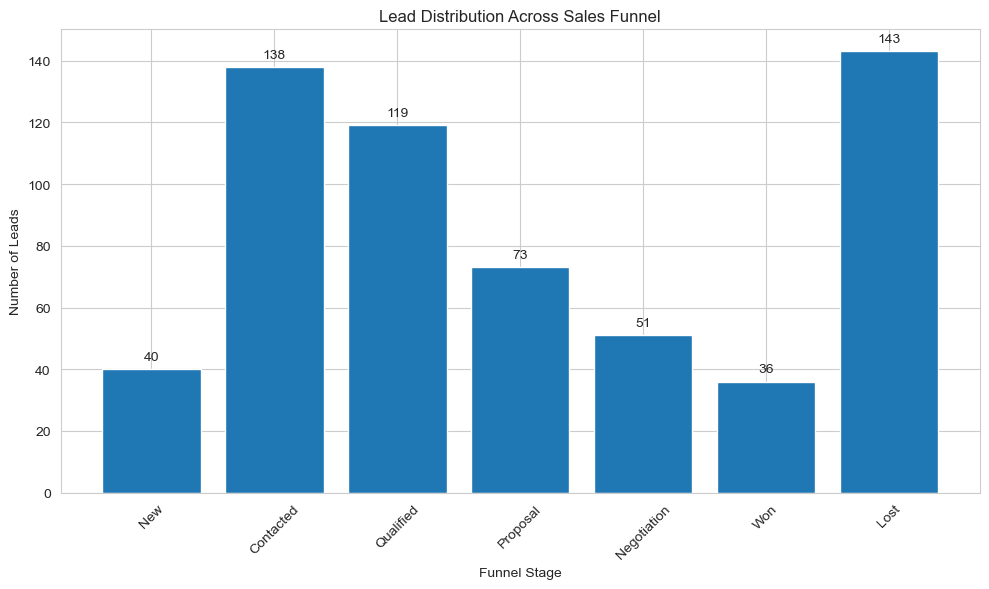

In [51]:
# =========================================================
# FUNNEL DISTRIBUTION VISUALIZATION
# =========================================================

# Create a new figure for the chart
# figsize controls chart width and height
plt.figure(figsize=(10, 6))

# Create a bar chart using the ordered funnel distribution
# x-axis = funnel stages
# y-axis = number of leads
plt.bar(
    ordered_funnel.index,
    ordered_funnel.values
)

# Add chart title
plt.title("Lead Distribution Across Sales Funnel")

# Label x-axis
plt.xlabel("Funnel Stage")

# Label y-axis
plt.ylabel("Number of Leads")

# Rotate x-axis labels slightly for readability
plt.xticks(rotation=45)

# Add exact values above each bar
for i, value in enumerate(ordered_funnel.values):
    
    # Place text above each bar
    plt.text(
        i,              # x position
        value + 3,      # y position (slightly above bar)
        str(value),     # text to display
        ha="center"     # horizontal alignment
    )

# Automatically adjust layout to prevent label cutoff
plt.tight_layout()

# Display the chart
plt.show()

## Funnel Visualization Findings

The visualization highlights a strong concentration of leads in the early and middle funnel stages, especially in `Contacted` and `Qualified`.

The `Lost` category contains the highest number of leads, indicating that a substantial portion of prospects fail to convert.

Additionally, the number of leads decreases considerably in later funnel stages, with only a small portion ultimately reaching the `Won` stage.

## Important Interpretation Note

This visualization represents the **current distribution of leads across statuses**, not a true historical funnel progression.

Therefore, the chart should not be interpreted as a sequential conversion funnel, since each lead appears only once with its current status.

As a result, stage counts may increase between consecutive statuses (for example, `New` to `Contacted`), which would not occur in a traditional funnel analysis.

## Overall Win Rate Analysis

The overall win rate measures the percentage of total leads that successfully converted into paying customers.

This metric provides a high-level KPI for evaluating the effectiveness of the sales pipeline from lead acquisition to deal closure.

In [52]:
# =========================================================
# OVERALL WIN RATE
# =========================================================

# Count leads with status "Won"
won_leads = (df["status"] == "Won").sum()

# Count total number of leads
total_leads = len(df)

# Calculate overall win rate
overall_win_rate = (won_leads / total_leads) * 100

# Display results
print(f"Won Leads: {won_leads}")
print(f"Total Leads: {total_leads}")
print(f"Overall Win Rate: {overall_win_rate:.2f}%")

Won Leads: 36
Total Leads: 600
Overall Win Rate: 6.00%


#### Overall Win Rate Findings

- Out of **600 total leads**, only **36 leads** reached the `Won` status
- The overall win rate is **6.00%**
- This means that only a small share of the total lead pipeline successfully converted into paying customers

This confirms that Nexus Digital has a meaningful conversion challenge at the overall pipeline level.

### Part 1 Summary — Funnel Analysis

The funnel analysis shows that Nexus Digital’s pipeline has a low overall conversion rate, with only **6.00%** of leads converting into customers.

Most leads are concentrated in the early and middle stages of the funnel, especially `Contacted` and `Qualified`, while relatively few reach `Won`.

Because the dataset contains only the current status of each lead, exact historical stage-to-stage conversion rates cannot be calculated reliably. However, the current distribution suggests that the main challenge is moving leads from mid-funnel stages toward final conversion.

============================================================

# Part 2 — Channel Performance Analysis

============================================================

In this section, we evaluate the performance of different lead acquisition channels.

We compare channels based on:
- Lead volume
- Conversion efficiency
- Average deal value

The goal is to identify which channels generate the highest-quality leads and which channels may be underperforming.

## Lead Volume by Acquisition Channel

We begin by analyzing the number of leads generated by each acquisition channel.

This helps identify which channels contribute the largest share of incoming leads and provides an initial view of marketing performance.

In [53]:
# =========================================================
# LEAD VOLUME BY ACQUISITION CHANNEL
# =========================================================

# Count the number of leads generated by each acquisition channel
# value_counts() counts how many times each channel appears
source_volume = df["lead_source"].value_counts()

# Display lead volume for each channel
source_volume

lead_source
Google Ads          108
LinkedIn Ads        101
Cold Email           89
Webinar              81
Organic Search       79
Content Download     51
Referral             46
Trade Show           45
Name: count, dtype: int64

## Lead Volume Findings

- `Google Ads` generated the highest lead volume with **108 leads** (18% of total leads)
- `LinkedIn Ads` ranked second with **101 leads**
- Lead generation is relatively diversified, with no single channel dominating the pipeline
- `Referral` and `Trade Show` generated the lowest lead volume among all acquisition channels

Lead volume alone does not indicate channel quality, so conversion performance must also be evaluated.

## Conversion Rate by Acquisition Channel

Next, we evaluate the conversion efficiency of each acquisition channel.

Instead of measuring lead volume alone, conversion rate helps determine which channels generate leads that are more likely to become paying customers.

In [54]:
# =========================================================
# CHANNEL CONVERSION RATE
# =========================================================

# Group leads by acquisition channel
# For each channel, count total leads and won leads
channel_conversion = df.groupby("lead_source").agg(
    total_leads=("lead_id", "count"),
    won_leads=("status", lambda x: (x == "Won").sum())
)

# Calculate conversion rate as percentage
channel_conversion["conversion_rate"] = (
    channel_conversion["won_leads"] /
    channel_conversion["total_leads"]
) * 100

# Round values for cleaner presentation
channel_conversion["conversion_rate"] = channel_conversion["conversion_rate"].round(2)

# Sort channels by highest conversion rate
channel_conversion = channel_conversion.sort_values(
    by="conversion_rate",
    ascending=False
)

# Display results
channel_conversion

,total_leads,won_leads,conversion_rate
lead_source,,,
Referral,46,8,17.39
Trade Show,45,4,8.89
Webinar,81,5,6.17
Content Download,51,3,5.88
Cold Email,89,5,5.62
Google Ads,108,6,5.56
Organic Search,79,4,5.06
LinkedIn Ads,101,1,0.99


## Channel Conversion Findings

- `Referral` achieved the highest conversion rate at **17.39%**, significantly above the overall pipeline average
- `Trade Show` ranked second with **8.89%**
- `LinkedIn Ads` showed the weakest performance, converting only **0.99%** of leads despite generating high lead volume
- The results suggest that lead volume alone does not guarantee high conversion quality

Channels generating fewer leads may still deliver significantly higher-quality prospects.

## Revenue Analysis Based on Closed-Won Deals

The previous channel analysis evaluated lead volume and conversion efficiency across acquisition channels.

For revenue analysis, we focus only on leads with status `Won` to ensure all monetary metrics reflect actual realized revenue rather than estimated pipeline values.

In [55]:
# =========================================================
# FILTER CLOSED-WON DEALS
# =========================================================

# Keep only leads that successfully converted into customers
won_df = df[df["status"] == "Won"]

# Display number of won deals
len(won_df)

36

## Average Won Deal Value by Acquisition Channel

We now compare the average deal value across acquisition channels using only closed-won deals.

This helps identify which channels generate higher-value customers.

In [56]:
# =========================================================
# AVERAGE WON DEAL VALUE BY CHANNEL
# =========================================================

# Group only won deals by acquisition channel
# Calculate average realized deal value for each channel
channel_deal_value = won_df.groupby("lead_source").agg(
    average_deal_value=("deal_value", "mean")
)

# Round values for cleaner presentation
channel_deal_value["average_deal_value"] = (
    channel_deal_value["average_deal_value"].round(2)
)

# Sort channels from highest to lowest average deal value
channel_deal_value = channel_deal_value.sort_values(
    by="average_deal_value",
    ascending=False
)

# Display results
channel_deal_value

,average_deal_value
lead_source,
Trade Show,"201,900.00"
Google Ads,"78,233.33"
Referral,"57,075.00"
LinkedIn Ads,"30,600.00"
Cold Email,"29,680.00"
Organic Search,"21,950.00"
Webinar,"15,860.00"
Content Download,"14,433.33"


## Average Won Deal Value Findings

- `Trade Show` generated the highest average won deal value at **$201,900**
- `Google Ads` ranked second with an average won deal value of **$78,233**
- `Content Download` produced the lowest average won deal value at **$14,433**
- This suggests that some channels generate fewer customers but significantly higher-value deals

## Total Realized Revenue by Acquisition Channel

In addition to average deal size, total realized revenue shows which acquisition channels contributed the most actual revenue.

This metric reflects only revenue from successfully closed deals.

In [57]:
# =========================================================
# TOTAL REALIZED REVENUE BY CHANNEL
# =========================================================

# Group only won deals by acquisition channel
# Sum actual revenue generated by each channel
channel_revenue = won_df.groupby("lead_source").agg(
    total_revenue=("deal_value", "sum")
)

# Round values for cleaner presentation
channel_revenue["total_revenue"] = (
    channel_revenue["total_revenue"].round(2)
)

# Sort channels from highest to lowest total revenue
channel_revenue = channel_revenue.sort_values(
    by="total_revenue",
    ascending=False
)

# Display results
channel_revenue

,total_revenue
lead_source,
Trade Show,807600
Google Ads,469400
Referral,456600
Cold Email,148400
Organic Search,87800
Webinar,79300
Content Download,43300
LinkedIn Ads,30600


## Total Realized Revenue Findings

- `Trade Show` generated the highest realized revenue at **$807,600**
- `Google Ads` ranked second with **$469,400**
- `Referral` delivered strong revenue despite relatively low lead volume, indicating high lead quality
- `LinkedIn Ads` generated the lowest realized revenue among channels despite high lead volume, suggesting severe underperformance

## Part 2 Summary

Channel performance varies significantly across acquisition sources.

- `Trade Show` emerged as the strongest overall channel, generating the highest average deal value and realized revenue
- `Referral` delivered the highest conversion rate, indicating exceptional lead quality
- `Google Ads` provided the highest lead volume and strong overall revenue contribution
- `LinkedIn Ads` significantly underperformed relative to its lead volume, generating very low conversion and realized revenue

These findings suggest that channel evaluation should consider volume, conversion, and realized revenue together rather than relying on a single KPI.

============================================================

# Part 3 — Campaign Deep Dive

============================================================

In this section, we analyze campaign-level performance within each acquisition channel.

The goal is to identify top-performing campaigns and detect campaigns that may need optimization, scaling, or discontinuation.

In [58]:
# =========================================================
# CAMPAIGN DISTRIBUTION
# =========================================================

# Count how many leads were generated by each campaign
campaign_volume = df["campaign_name"].value_counts()

# Display campaign lead distribution
campaign_volume

campaign_name
LI_Tech_Leaders               34
GoogQ3_Retargeting            32
LI_Industry_Vertical          28
Webinar_Data_Strategy         28
GoogQ2_Product_Launch         27
GoogQ1_Brand_Awareness        25
GoogQ4_Holiday_Push           24
ColdEmail_Series_A            24
LI_CFO_Suite                  23
ColdEmail_Vertical_Blast      23
SEO_Comparison_Articles       22
Webinar_Cloud_Migration       22
ColdEmail_Enterprise_Push     21
ColdEmail_Re_Engagement       21
SEO_Blog_Inbound              20
SEO_Product_Pages             20
SEO_Case_Studies              17
Referral_Partner_Program      17
Referral_Employee             17
LI_Decision_Makers            16
Content_Ebook_Analytics       16
Webinar_Security_Best         16
Webinar_AI_Trends_2025        15
Content_Whitepaper_AI         15
TradeShow_SaaStr              13
TradeShow_Dreamforce          12
Referral_Customer_Advocacy    12
TradeShow_WebSummit           11
Content_ROI_Calculator        11
Content_Template_Pack        

## Campaign Conversion Rate

We now evaluate conversion performance at the campaign level.

This helps identify which campaigns generate the highest-quality leads and which campaigns may require optimization.

> Note: Campaigns with small lead volumes should be interpreted cautiously, as conversion rates may be more sensitive to small sample sizes.

In [59]:
# =========================================================
# CAMPAIGN CONVERSION RATE
# =========================================================

# groupby("campaign_name") tells pandas:
# "Take all rows in the dataframe and group them by campaign name"
# Example:
# All rows of LI_Tech_Leaders go together
# All rows of GoogQ3_Retargeting go together
campaign_conversion = df.groupby("campaign_name").agg(

    # Create a new column called total_leads
    # Count how many rows (leads) belong to each campaign
    # Each row represents one lead
    total_leads=("lead_id", "count"),

    # Create another new column called won_leads
    # Here we use a custom function (lambda) on the status column
    won_leads=(
        "status",

        # lambda creates a short temporary function
        # x represents all status values inside one campaign group
        # Example x might look like:
        # ["Won", "Lost", "Won", "Qualified"]

        # (x == "Won") converts each value to True/False:
        # ["Won","Lost","Won"] -> [True, False, True]

        # sum() treats True as 1 and False as 0
        # So sum() counts how many Won values exist
        lambda x: (x == "Won").sum()
    )
)

# Calculate campaign conversion rate
# Formula:
# (number of won leads / total leads) * 100
campaign_conversion["conversion_rate"] = (
    campaign_conversion["won_leads"] /
    campaign_conversion["total_leads"]
) * 100

# Round conversion rate to 2 decimal places
# Makes the output cleaner and easier to read
campaign_conversion["conversion_rate"] = (
    campaign_conversion["conversion_rate"].round(2)
)

# Sort the table by conversion rate
# Highest conversion campaigns appear first
campaign_conversion = campaign_conversion.sort_values(
    by="conversion_rate",
    ascending=False
)

# Display final table
campaign_conversion

,total_leads,won_leads,conversion_rate
campaign_name,,,
Referral_Partner_Program,17,5,29.41
Content_Template_Pack,9,2,22.22
TradeShow_Dreamforce,12,2,16.67
Webinar_Data_Strategy,28,4,14.29
Referral_Employee,17,2,11.76
TradeShow_CES_2025,9,1,11.11
Content_ROI_Calculator,11,1,9.09
ColdEmail_Series_A,24,2,8.33
Referral_Customer_Advocacy,12,1,8.33


## Campaign Revenue Analysis

Conversion rate alone does not fully capture campaign performance.

We also analyze realized revenue to identify campaigns that generate the highest actual business value.

In [60]:
# =========================================================
# CAMPAIGN REVENUE ANALYSIS
# =========================================================

# First, use only won deals because we want REAL revenue
# and not estimated pipeline value
campaign_revenue = won_df.groupby("campaign_name").agg(

    # Create a new column called total_revenue
    # Sum all deal values inside each campaign
    # Example:
    # Campaign A won deals = 50k + 80k + 20k
    # total_revenue = 150k
    total_revenue=("deal_value", "sum")
)

# Round revenue values to 2 decimal places
# Mostly for cleaner presentation
campaign_revenue["total_revenue"] = (
    campaign_revenue["total_revenue"].round(2)
)

# Sort campaigns by revenue from highest to lowest
# Top revenue campaigns will appear first
campaign_revenue = campaign_revenue.sort_values(
    by="total_revenue",
    ascending=False
)

# Display final revenue table
campaign_revenue

,total_revenue
campaign_name,
TradeShow_CES_2025,448400
GoogQ2_Product_Launch,313900
TradeShow_Dreamforce,267300
Referral_Employee,236300
Referral_Partner_Program,212800
GoogQ1_Brand_Awareness,95800
TradeShow_SaaStr,91900
ColdEmail_Vertical_Blast,64400
Webinar_Data_Strategy,56300


## Campaign Deep Dive Findings

- `TradeShow_CES_2025` generated the highest realized revenue at **$448,400**
- `Referral_Partner_Program` achieved the highest conversion rate (**29.41%**), indicating exceptional lead quality
- Multiple `Trade Show` campaigns consistently ranked among the top revenue generators
- Most `LinkedIn Ads` campaigns showed extremely weak performance, with several campaigns generating zero closed-won deals

These findings suggest that Trade Show and Referral campaigns should be considered for scaling, while LinkedIn campaigns may require optimization, budget reduction, or strategic reassessment.

## Top Campaigns by Realized Revenue

To make campaign performance easier to interpret, we visualize the top campaigns based on actual realized revenue.

This highlights which campaigns generated the most closed-won business value.

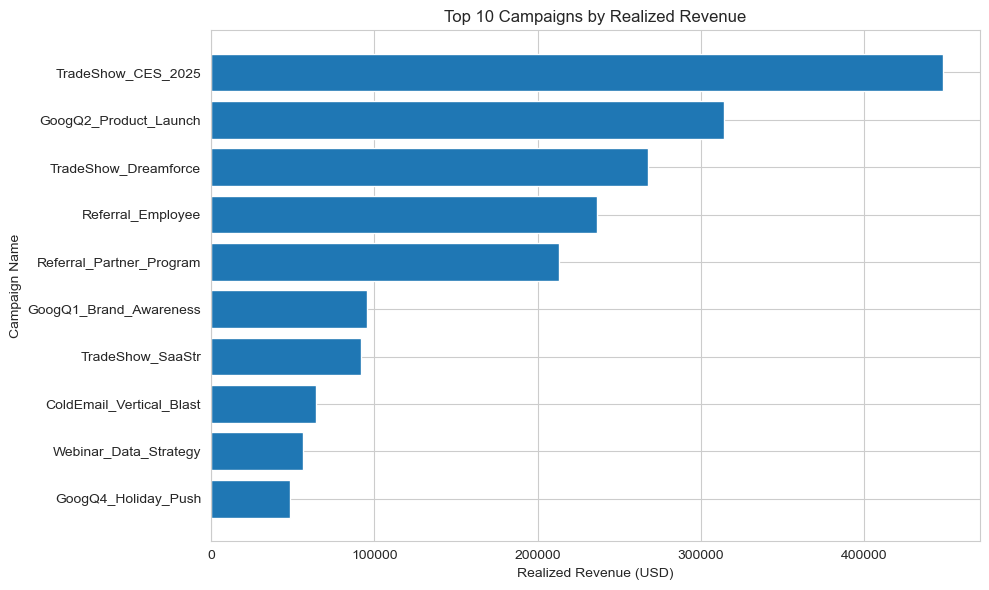

In [61]:
# =========================================================
# TOP CAMPAIGNS BY REALIZED REVENUE
# =========================================================

# Select the top 10 campaigns based on realized revenue
# campaign_revenue is already sorted from highest to lowest
top_10_campaigns = campaign_revenue.head(10)

# Create the chart canvas
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart
plt.barh(
    top_10_campaigns.index,
    top_10_campaigns["total_revenue"]
)

# Add chart title
plt.title("Top 10 Campaigns by Realized Revenue")

# Label x-axis
plt.xlabel("Realized Revenue (USD)")

# Label y-axis
plt.ylabel("Campaign Name")

# Invert y-axis so the highest revenue campaign appears at the top
plt.gca().invert_yaxis()

# Adjust layout so campaign names are not cut off
plt.tight_layout()

# Display the chart
plt.show()

## Campaign Deep Dive Summary

Campaign-level analysis revealed significant performance differences within acquisition channels.

### Top Performing Campaigns
- `TradeShow_CES_2025` generated the highest realized revenue at **$448,400**
- `TradeShow_Dreamforce` and `GoogQ2_Product_Launch` also delivered strong revenue performance
- `Referral_Partner_Program` achieved the highest conversion rate (**29.41%**), indicating exceptional lead quality
- `Referral_Employee` combined strong conversion with high realized revenue

### Underperforming Campaigns
- Most `LinkedIn Ads` campaigns showed very weak performance
- Several LinkedIn campaigns generated **zero closed-won deals**
- Despite relatively high lead volume, LinkedIn campaigns contributed minimal realized revenue

### Business Interpretation
These findings suggest that budget allocation at the campaign level should prioritize high-performing Trade Show and Referral campaigns.

At the same time, low-performing LinkedIn campaigns should be reviewed for targeting, messaging, or potential budget reduction.

> Note: Some campaign-level results should be interpreted cautiously due to relatively small sample sizes.

============================================================

# Question 4 — Sales Rep Performance

============================================================

In this section, we evaluate sales representative performance across three key dimensions:

1. Conversion rate  
2. Response time to first contact  
3. Average closed-won deal value  

The goal is to identify performance differences across reps and determine whether any rep may require coaching or operational support.

## Sales Rep Conversion Rate

We begin by comparing conversion performance across sales representatives.

Conversion rate measures how effectively each rep turns assigned leads into closed-won customers.

In [62]:
# =========================================================
# SALES REP CONVERSION RATE
# =========================================================

# Group all leads by assigned sales representative
# This creates one group per rep
rep_conversion = df.groupby("assigned_rep").agg(

    # Count total leads assigned to each rep
    # Each row represents one lead
    total_leads=("lead_id", "count"),

    # Count how many leads reached status = "Won"
    won_leads=(
        "status",

        # Lambda function explanation:
        # x contains all status values for one rep
        # Example:
        # ["Won", "Lost", "Qualified", "Won"]
        #
        # (x == "Won") converts this into:
        # [True, False, False, True]
        #
        # sum() counts True values as 1
        lambda x: (x == "Won").sum()
    )
)

# Calculate conversion rate percentage
# Formula:
# Won leads / Total leads * 100
rep_conversion["conversion_rate"] = (
    rep_conversion["won_leads"] /
    rep_conversion["total_leads"]
) * 100

# Round values to 2 decimal places
rep_conversion["conversion_rate"] = (
    rep_conversion["conversion_rate"].round(2)
)

# Sort reps from highest conversion to lowest
rep_conversion = rep_conversion.sort_values(
    by="conversion_rate",
    ascending=False
)

# Display results
rep_conversion

,total_leads,won_leads,conversion_rate
assigned_rep,,,
Sarah Chen,101,12,11.88
Emily Rodriguez,108,11,10.19
Olivia Foster,93,5,5.38
James Morrison,97,3,3.09
Marcus Webb,116,3,2.59
David Park,85,2,2.35


## Sales Rep Response Time

Next, we compare the average response time of each sales representative.

This helps evaluate whether slower first-contact speed may be affecting conversion performance.

In [63]:
# =========================================================
# SALES REP RESPONSE TIME
# =========================================================

# Group dataframe by sales rep
rep_response = df.groupby("assigned_rep").agg(

    # Calculate average response time
    # days_to_first_contact stores how long it took
    # for the rep to contact the lead
    avg_response_time=(
        "days_to_first_contact",
        "mean"
    )
)

# Round response times to 2 decimal places
rep_response["avg_response_time"] = (
    rep_response["avg_response_time"].round(2)
)

# Sort from fastest rep to slowest rep
# Lower response time = better
rep_response = rep_response.sort_values(
    by="avg_response_time",
    ascending=True
)

# Display results
rep_response

,avg_response_time
assigned_rep,
Sarah Chen,7.53
Emily Rodriguez,12.58
David Park,17.18
James Morrison,18.21
Olivia Foster,20.52
Marcus Webb,41.39


## Response Time Findings

- `Sarah Chen` had the fastest average response time at **7.53 hours**
- `Marcus Webb` had the slowest response time at **41.39 hours**
- A preliminary pattern suggests that faster response times may be associated with better conversion performance

> Important note: Although the column is named `days_to_first_contact`, the dataset documentation specifies that this metric is actually measured in hours, not days.

## Average Won Deal Value by Sales Rep

Finally, we compare the average value of successfully closed deals across sales representatives.

This helps determine whether certain reps specialize in larger or higher-value deals.

In [64]:
# =========================================================
# AVERAGE WON DEAL VALUE BY SALES REP
# =========================================================

# Use only closed-won deals
# We already created won_df earlier:
# won_df = df[df["status"] == "Won"]

# Group all won deals by sales representative
rep_deal_value = won_df.groupby("assigned_rep").agg(

    # Calculate average deal value for each rep
    # mean = average value
    avg_won_deal_value=(
        "deal_value",
        "mean"
    )
)

# Round values to 2 decimal places
rep_deal_value["avg_won_deal_value"] = (
    rep_deal_value["avg_won_deal_value"].round(2)
)

# Sort from highest average deal value to lowest
rep_deal_value = rep_deal_value.sort_values(
    by="avg_won_deal_value",
    ascending=False
)

# Display final table
rep_deal_value

,avg_won_deal_value
assigned_rep,
Marcus Webb,"280,866.67"
Emily Rodriguez,"56,427.27"
David Park,"43,650.00"
Sarah Chen,"38,000.00"
Olivia Foster,"17,300.00"
James Morrison,"9,966.67"


## Sales Rep Performance Visualization

The following scatter plot compares sales representatives based on response speed and conversion performance.

Each point represents a sales rep.

Interpretation guide:

- Top-left → Fast response + High conversion (best overall performance)
- Bottom-right → Slow response + Low conversion (potential coaching candidates)

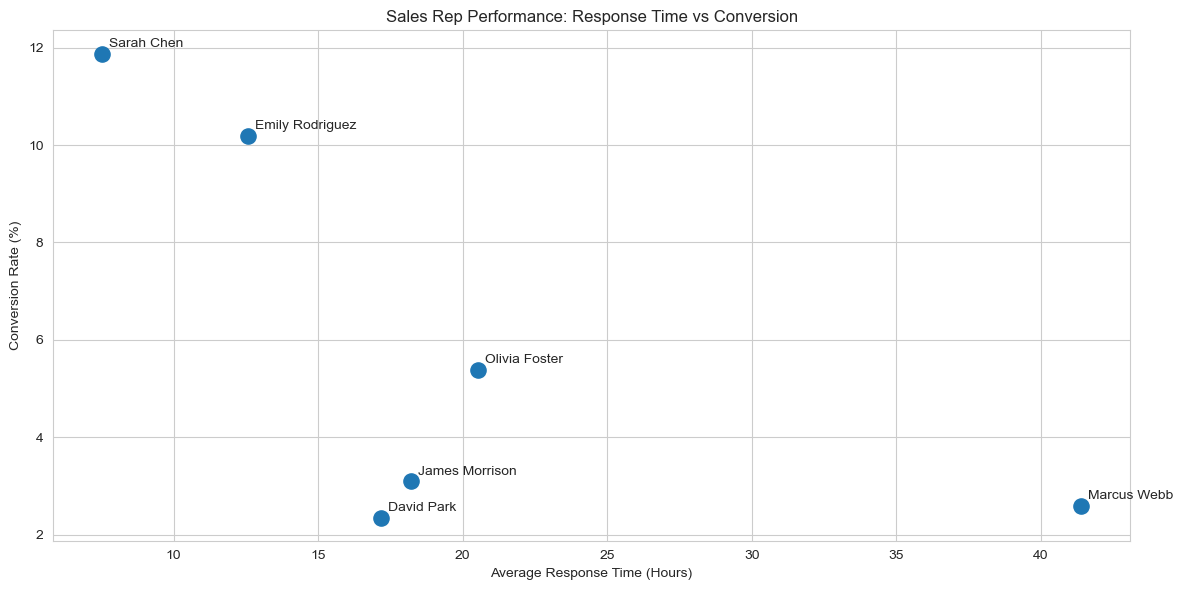

In [65]:
# =========================================================
# SALES REP PERFORMANCE SCATTER PLOT
# =========================================================

# Merge conversion and response tables into one dataframe
# We need both metrics in the same table for plotting
rep_performance = rep_conversion.join(rep_response)

# Create chart canvas
plt.figure(figsize=(12, 6))

# Create scatter plot
# X-axis = average response time (hours)
# Y-axis = conversion rate (%)
plt.scatter(
    rep_performance["avg_response_time"],
    rep_performance["conversion_rate"],
    s=120   # controls dot size
)

# Add labels for each rep
# iterrows() loops through dataframe row by row
for rep_name, row in rep_performance.iterrows():

    plt.annotate(
        rep_name,   # text to display
        (
            row["avg_response_time"],
            row["conversion_rate"]
        ),
        xytext=(5, 5),      # slight offset from dot
        textcoords="offset points"
    )

# Add chart title
plt.title("Sales Rep Performance: Response Time vs Conversion")

# Label x-axis
plt.xlabel("Average Response Time (Hours)")

# Label y-axis
plt.ylabel("Conversion Rate (%)")

# Add grid for easier reading
plt.grid(True)

# Prevent label cutoff
plt.tight_layout()

# Display chart
plt.show()

## Sales Rep Bubble Analysis

To better understand rep performance, we visualize three metrics simultaneously:

- X-axis → Average response time (hours)
- Y-axis → Conversion rate (%)
- Bubble size → Average won deal value

This helps identify whether reps with lower conversion may still generate high-value deals.

In [66]:
# =========================================================
# COMBINE ALL SALES REP METRICS
# =========================================================

# Start from conversion table
rep_full = rep_conversion.join(rep_response)

# Join average deal value table as well
rep_full = rep_full.join(rep_deal_value)

# Display combined table
rep_full

,total_leads,won_leads,conversion_rate,avg_response_time,avg_won_deal_value
assigned_rep,,,,,
Sarah Chen,101,12,11.88,7.53,"38,000.00"
Emily Rodriguez,108,11,10.19,12.58,"56,427.27"
Olivia Foster,93,5,5.38,20.52,"17,300.00"
James Morrison,97,3,3.09,18.21,"9,966.67"
Marcus Webb,116,3,2.59,41.39,"280,866.67"
David Park,85,2,2.35,17.18,"43,650.00"


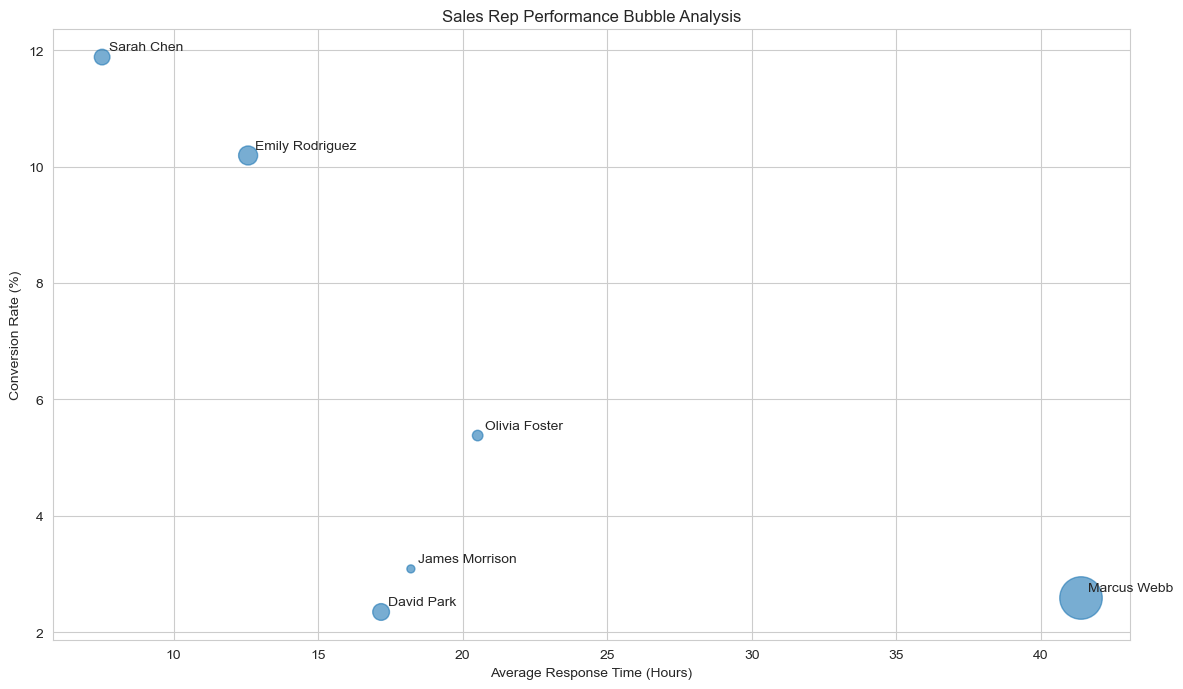

In [67]:
# =========================================================
# SALES REP BUBBLE CHART
# =========================================================

# Create chart canvas
plt.figure(figsize=(12, 7))

# Create bubble chart
# X-axis = response time
# Y-axis = conversion rate
# Bubble size = average won deal value
plt.scatter(
    rep_full["avg_response_time"],
    rep_full["conversion_rate"],

    # Bubble size
    # We divide by 300 so bubbles don't become enormous
    s=rep_full["avg_won_deal_value"] / 300,

    alpha=0.6
)

# Add labels for each rep
for rep_name, row in rep_full.iterrows():
    plt.annotate(
        rep_name,
        (
            row["avg_response_time"],
            row["conversion_rate"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Add chart title
plt.title("Sales Rep Performance Bubble Analysis")

# Label x-axis
plt.xlabel("Average Response Time (Hours)")

# Label y-axis
plt.ylabel("Conversion Rate (%)")

# Add grid
plt.grid(True)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

> Bubble size represents average closed-won deal value (USD). Larger bubbles indicate higher average revenue per won deal.

## Sales Rep Performance Findings

- `Sarah Chen` demonstrated the strongest overall performance, combining the highest conversion rate (**11.88%**) with the fastest response time (**7.53 hours**)
- `Emily Rodriguez` also performed strongly, showing high conversion and relatively fast response times
- A pattern suggests that faster response times may contribute to stronger conversion performance
- `Marcus Webb` had one of the lowest conversion rates and slowest response times, but generated by far the highest average won deal value (**$280,866.67**)

This suggests that sales rep performance should not be evaluated based on conversion rate alone.

`Marcus Webb` may be handling larger enterprise accounts with longer sales cycles and higher-value opportunities.

============================================================

# Question 5 — Response Time Impact

============================================================

In this section, we analyze how response speed affects lead conversion.

The goal is to determine whether delayed first contact reduces conversion probability and identify any critical threshold after which leads become significantly less likely to convert.

## Response Time Buckets

To analyze how response speed affects conversion, response times are grouped into time buckets.

This simplifies analysis by transforming raw response-hour values into business-friendly categories that can be compared more easily.

In [68]:
# =========================================================
# RESPONSE TIME BUCKETS
# =========================================================

# Create response time buckets (in HOURS)
# Important:
# Although the column name says "days",
# the data dictionary confirms the metric is measured in hours

df["response_bucket"] = pd.cut(

    # Column to split into buckets
    df["days_to_first_contact"],

    # Bucket boundaries
    # 0-8h, 8-24h, 24-48h, 48h+
    bins=[0, 8, 24, 48, float("inf")],

    # Labels for each bucket
    labels=["0-8h", "8-24h", "24-48h", "48h+"]
)

# Count how many leads fall into each bucket
df["response_bucket"].value_counts()

response_bucket
8-24h     225
0-8h      189
24-48h    139
48h+       47
Name: count, dtype: int64

## Conversion Rate by Response Bucket

Next, we calculate conversion rates for each response-time bucket to determine whether faster response leads to higher conversion.

In [69]:
# =========================================================
# CONVERSION RATE BY RESPONSE BUCKET
# =========================================================

# Group leads by response bucket
bucket_conversion = df.groupby("response_bucket").agg(

    # Count total leads in each bucket
    total_leads=("lead_id", "count"),

    # Count won leads in each bucket
    won_leads=(
        "status",
        lambda x: (x == "Won").sum()
    )
)

# Calculate conversion rate percentage
bucket_conversion["conversion_rate"] = (
    bucket_conversion["won_leads"] /
    bucket_conversion["total_leads"]
) * 100

# Round conversion rate
bucket_conversion["conversion_rate"] = (
    bucket_conversion["conversion_rate"].round(2)
)

# Display results
bucket_conversion

,total_leads,won_leads,conversion_rate
response_bucket,,,
0-8h,189,14,7.41
8-24h,225,14,6.22
24-48h,139,7,5.04
48h+,47,1,2.13


## Response Time Impact Findings

- Conversion rate declines consistently as response time increases
- Leads contacted within **0–8 hours** achieved the highest conversion rate (**7.41%**)
- Leads contacted after **48+ hours** showed the lowest conversion rate (**2.13%**)
- The sharpest drop occurs after 48 hours, where conversion falls by nearly 60%

This suggests that delayed outreach significantly reduces the probability of closing a deal.

A response delay beyond 48 hours appears to be a critical threshold where leads begin to go cold.

## Response Time Impact Visualization

The following trend line illustrates how conversion rate changes as response time increases.

This helps identify whether slower outreach reduces lead conversion and highlights any critical response-time threshold.

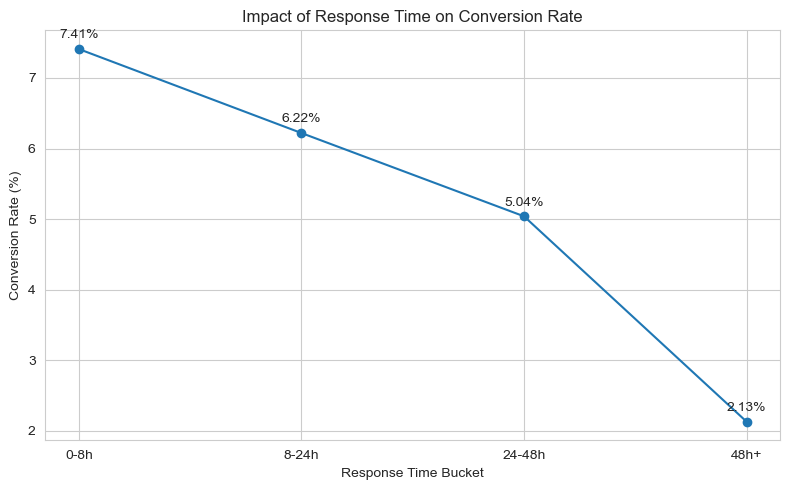

In [70]:
# =========================================================
# RESPONSE TIME IMPACT LINE CHART
# =========================================================

# Create chart canvas
plt.figure(figsize=(8, 5))

# Create line chart
plt.plot(
    bucket_conversion.index.astype(str),
    bucket_conversion["conversion_rate"],
    marker="o"   # Adds dots on each data point
)

# Add value labels above each point
for i, value in enumerate(bucket_conversion["conversion_rate"]):
    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

# Add chart title
plt.title("Impact of Response Time on Conversion Rate")

# Label x-axis
plt.xlabel("Response Time Bucket")

# Label y-axis
plt.ylabel("Conversion Rate (%)")

# Add grid
plt.grid(True)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

============================================================

# Question 6 — Lead Scoring Accuracy

============================================================

In this section, we evaluate whether higher lead scores are associated with higher conversion rates.

The objective is to assess whether the lead scoring model reliably predicts lead quality and conversion likelihood.

## Lead Score Buckets

To analyze scoring effectiveness, lead scores are grouped into score brackets.

This makes it easier to compare conversion behavior across low-, medium-, and high-scoring leads.

In [71]:
# =========================================================
# LEAD SCORE BUCKETS
# =========================================================

# Create lead score buckets
df["score_bucket"] = pd.cut(

    # Column to bucket
    df["lead_score"],

    # Score boundaries
    bins=[0, 20, 40, 60, 80, 100],

    # Labels for each bucket
    labels=[
        "0-20",
        "20-40",
        "40-60",
        "60-80",
        "80-100"
    ],

    # Include score = 0
    include_lowest=True
)

# Count leads in each score bucket
df["score_bucket"].value_counts().sort_index()

score_bucket
0-20       22
20-40     136
40-60     233
60-80     173
80-100     36
Name: count, dtype: int64

## Conversion Rate by Lead Score

Next, we calculate conversion rates across lead-score buckets to evaluate whether higher scores correspond to higher conversion probability.

In [72]:
# =========================================================
# CONVERSION RATE BY SCORE BUCKET
# =========================================================

# Group leads by score bucket
score_conversion = df.groupby("score_bucket").agg(

    # Count total leads in each score range
    total_leads=("lead_id", "count"),

    # Count how many became closed-won deals
    won_leads=(
        "status",
        lambda x: (x == "Won").sum()
    )
)

# Calculate conversion rate percentage
score_conversion["conversion_rate"] = (
    score_conversion["won_leads"] /
    score_conversion["total_leads"]
) * 100

# Round for cleaner display
score_conversion["conversion_rate"] = (
    score_conversion["conversion_rate"].round(2)
)

# Display table
score_conversion

,total_leads,won_leads,conversion_rate
score_bucket,,,
0-20,22,2,9.09
20-40,136,13,9.56
40-60,233,9,3.86
60-80,173,9,5.20
80-100,36,3,8.33


## Alternative Scoring Analysis (3-Bucket Model)

Because extreme score ranges contain relatively few leads, the original 5-bucket segmentation may introduce statistical noise.

To reduce variance and test scoring reliability more robustly, lead scores are regrouped into three broader categories: Low, Medium, and High.

In [73]:
# =========================================================
# ALTERNATIVE LEAD SCORE BUCKETS (3 BUCKETS)
# =========================================================

# Create broader score buckets to reduce noise
df["score_bucket_3"] = pd.cut(

    # Column to split
    df["lead_score"],

    # Bucket boundaries
    bins=[0, 33, 66, 100],

    # Labels
    labels=[
        "Low (0-33)",
        "Medium (34-66)",
        "High (67-100)"
    ],

    include_lowest=True
)

# Count leads in each bucket
df["score_bucket_3"].value_counts().sort_index()

score_bucket_3
Low (0-33)         90
Medium (34-66)    365
High (67-100)     145
Name: count, dtype: int64

## Conversion Rate by 3-Bucket Score Model

Next, conversion rates are recalculated using the broader score segmentation to evaluate whether lead score shows clearer predictive power when statistical noise is reduced.

In [74]:
# =========================================================
# CONVERSION RATE BY 3 SCORE BUCKETS
# =========================================================

# Group leads by 3-bucket score model
score_conversion_3 = df.groupby("score_bucket_3").agg(

    # Count total leads in each bucket
    total_leads=("lead_id", "count"),

    # Count closed-won deals
    won_leads=(
        "status",
        lambda x: (x == "Won").sum()
    )
)

# Calculate conversion rate
score_conversion_3["conversion_rate"] = (
    score_conversion_3["won_leads"] /
    score_conversion_3["total_leads"]
) * 100

# Round values
score_conversion_3["conversion_rate"] = (
    score_conversion_3["conversion_rate"].round(2)
)

# Display results
score_conversion_3

,total_leads,won_leads,conversion_rate
score_bucket_3,,,
Low (0-33),90,5,5.56
Medium (34-66),365,20,5.48
High (67-100),145,11,7.59


## Lead Scoring Findings

The alternative 3-bucket analysis reveals that the lead scoring model provides some predictive value, but its overall effectiveness appears limited.

- High-scoring leads (67–100) achieved the highest conversion rate (**7.59%**)
- Low- and medium-scoring leads showed nearly identical conversion rates (**5.56%** vs **5.48%**)

This suggests that the scoring model can identify top-quality leads to some extent, but struggles to clearly distinguish between low- and medium-quality leads.

Overall, the model demonstrates moderate predictive power rather than strong scoring accuracy.

## Lead Score Performance Across Industries

To further evaluate scoring quality, we analyze conversion rates across industries and score buckets.

This helps identify whether lead score reliability is consistent across industries or whether predictive power weakens in specific market segments.

In [75]:
# =========================================================
# CONVERSION RATE BY INDUSTRY AND SCORE BUCKET
# =========================================================

# Group leads by BOTH industry and score bucket
# This creates smaller groups such as:
# Technology + High score
# Finance + Low score
industry_score = df.groupby(
    ["industry", "score_bucket_3"]
).agg(

    # Count total leads in each group
    total_leads=("lead_id", "count"),

    # Count how many leads became customers
    # lambda checks each status value:
    # True if status == "Won"
    # False otherwise
    # sum() counts all True values
    won_leads=(
        "status",
        lambda x: (x == "Won").sum()
    )
)

# Calculate conversion rate for each industry-score combination
industry_score["conversion_rate"] = (
    industry_score["won_leads"] /
    industry_score["total_leads"]
) * 100

# Round for cleaner presentation
industry_score["conversion_rate"] = (
    industry_score["conversion_rate"].round(2)
)

# Display results
industry_score

total_leads  won_leads  conversion_rate
industry      score_bucket_3                                         
Education     Low (0-33)               11          0             0.00
              Medium (34-66)           23          1             4.35
              High (67-100)            16          1             6.25
Finance       Low (0-33)               11          0             0.00
              Medium (34-66)           37          1             2.70
              High (67-100)            24          1             4.17
Healthcare    Low (0-33)               19          2            10.53
              Medium (34-66)           61          1             1.64
              High (67-100)            18          2            11.11
Manufacturing Low (0-33)               10          1            10.00
              Medium (34-66)           41          4             9.76
              High (67-100)            12          2            16.67
Real Estate   Low (0-33)                9          1            11.11
              Medium (34-66)           26          0             0.00
              High (67-100)            13          1             7.69
Retail        Low (0-33)               19          1             5.26
              Medium (34-66)           70          7            10.00
              High (67-100)            19          0             0.00
Technology    Low (0-33)               11          0             0.00
              Medium (34-66)          107          6             5.61
              High (67-100)            43          4             9.30

## Industry Comparison Pivot Table

To make cross-industry comparison easier, the conversion-rate results are reshaped into a pivot table.

This allows direct comparison of low-, medium-, and high-scoring leads across industries.

In [76]:
# =========================================================
# PIVOT TABLE FOR INDUSTRY COMPARISON
# =========================================================

# Convert grouped table into pivot format
industry_pivot = industry_score.reset_index().pivot(

    # Rows = industries
    index="industry",

    # Columns = score buckets
    columns="score_bucket_3",

    # Values = conversion rate
    values="conversion_rate"
)

# Display pivot table
industry_pivot

score_bucket_3,Low (0-33),Medium (34-66),High (67-100)
industry,,,
Education,0.00,4.35,6.25
Finance,0.00,2.70,4.17
Healthcare,10.53,1.64,11.11
Manufacturing,10.00,9.76,16.67
Real Estate,11.11,0.00,7.69
Retail,5.26,10.00,0.00
Technology,0.00,5.61,9.30


## Industry-Level Lead Scoring Findings

The industry breakdown reveals that lead score effectiveness varies significantly across industries.

- In **Technology**, **Education**, and **Finance**, higher lead scores are associated with higher conversion rates, suggesting that the scoring model performs reasonably well in these segments.
- In industries such as **Retail**, **Real Estate**, and **Healthcare**, the relationship between score and conversion is inconsistent.
- Some industries show unexpected patterns where low-scoring leads outperform medium- or high-scoring leads.

These findings suggest that the lead scoring model does not generalize equally across all industries.

Overall, the scoring model appears useful for identifying high-quality leads in certain industries, but its predictive power weakens in others, indicating that industry-specific score calibration may improve performance.

============================================================

# Question 7 — Seasonality Analysis

============================================================

In this section, we examine whether lead generation and conversion performance vary across months and quarters.

The goal is to identify seasonal patterns in lead volume, conversion rates, and deal value.

## Date Feature Extraction

Before analyzing seasonality, we extract month and quarter information from the lead creation date.

This allows us to group leads by time period and evaluate monthly or quarterly trends in lead volume, conversion rate, and deal value.

In [77]:
df["created_date"] = pd.to_datetime(
    df["created_date"],
    dayfirst=True,
    errors="coerce"
)

df["last_activity_date"] = pd.to_datetime(
    df["last_activity_date"],
    dayfirst=True,
    errors="coerce"
)

In [78]:
# =========================================================
# EXTRACT MONTH AND QUARTER FROM DATE
# =========================================================

# created_date was parsed as datetime at load (dayfirst=True)

# Extract month number
df["month"] = df["created_date"].dt.month

# Extract quarter number
df["quarter"] = df["created_date"].dt.quarter

# Verify conversion
df[["created_date", "month", "quarter"]].head()

,created_date,month,quarter
0,2024-04-08,4,2
1,2024-05-11,5,2
2,2024-05-07,5,2
3,2024-09-22,9,3
4,2024-04-05,4,2


## Monthly Lead Volume

We begin the seasonality analysis by counting how many leads were created in each month.

This helps identify whether lead generation volume changes throughout the year.

In [79]:
# =========================================================
# MONTHLY LEAD VOLUME
# =========================================================

# Group leads by month
# Count how many leads were created in each month
monthly_leads = df.groupby("month").agg(
    total_leads=("lead_id", "count")
)

# Display monthly lead volume
monthly_leads

,total_leads
month,
1,46
2,52
3,66
4,41
5,46
6,48
7,57
8,62
9,49


## Monthly Lead Volume Visualization

The following chart visualizes lead volume by month to identify seasonal fluctuations in lead generation throughout the year.

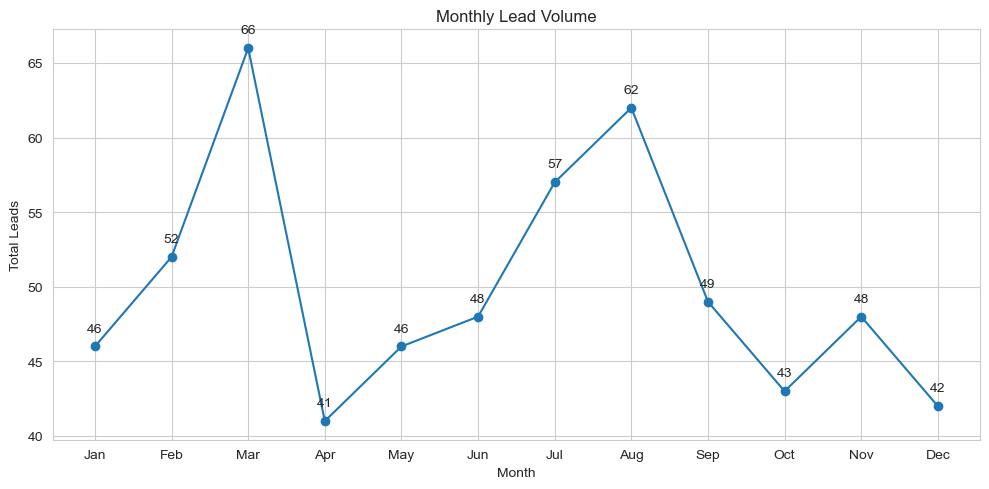

In [80]:
# =========================================================
# MONTHLY LEAD VOLUME VISUALIZATION
# =========================================================

# Create chart canvas
plt.figure(figsize=(10, 5))

# Plot monthly lead volume
plt.plot(
    monthly_leads.index,
    monthly_leads["total_leads"],
    marker="o"
)

# Add value labels above each point
for month, leads in zip(
    monthly_leads.index,
    monthly_leads["total_leads"]
):
    plt.text(
        month,
        leads + 1,
        str(leads),
        ha="center"
    )

# Add chart title
plt.title("Monthly Lead Volume")

# Label x-axis
plt.xlabel("Month")

# Label y-axis
plt.ylabel("Total Leads")

# Add grid
plt.grid(True)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]
plt.xticks(
    ticks=monthly_leads.index,
    labels=month_names,
    rotation=0
)
plt.tight_layout()
plt.show()

## Monthly Lead Volume Findings

The monthly lead volume analysis shows moderate seasonal fluctuations throughout the year, with no extreme seasonality observed.

- **March** recorded the highest lead volume with **66 leads**, indicating a noticeable peak in lead generation.
- A second strong period appears during **July–August**, with **57** and **62 leads** respectively.
- **April** recorded the lowest lead volume with **41 leads**, representing the sharpest monthly decline.
- Lead volume remained relatively stable across most other months, generally ranging between **42 and 52 leads**.

Overall, lead generation appears fairly consistent throughout the year, with only mild seasonal peaks rather than strong cyclical patterns.

## Monthly Conversion Rate

Next, we analyze conversion rates by month to determine whether leads generated in certain months are more likely to convert into customers.

In [81]:
# =========================================================
# MONTHLY CONVERSION RATE
# =========================================================

# Group leads by month
monthly_conversion = df.groupby("month").agg(

    # Count total leads per month
    total_leads=("lead_id", "count"),

    # Count won deals
    won_leads=(
        "status",
        lambda x: (x == "Won").sum()
    )
)

# Calculate conversion rate
monthly_conversion["conversion_rate"] = (
    monthly_conversion["won_leads"] /
    monthly_conversion["total_leads"]
) * 100

# Round for cleaner display
monthly_conversion["conversion_rate"] = (
    monthly_conversion["conversion_rate"].round(2)
)

# Display results
monthly_conversion

,total_leads,won_leads,conversion_rate
month,,,
1,46,1,2.17
2,52,5,9.62
3,66,6,9.09
4,41,0,0.00
5,46,4,8.70
6,48,1,2.08
7,57,3,5.26
8,62,3,4.84
9,49,2,4.08


## Monthly Conversion Rate Visualization

The following chart visualizes conversion rates across months to identify seasonal patterns in lead quality and sales effectiveness.

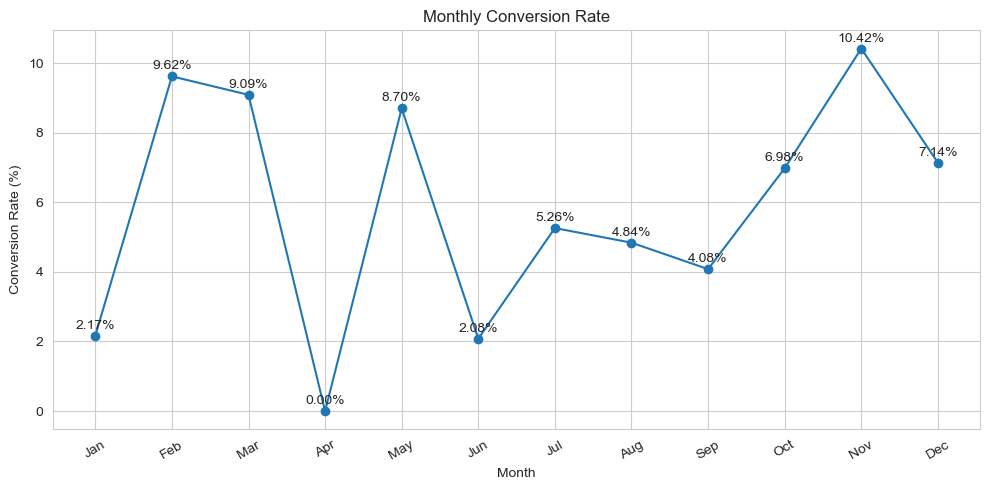

In [82]:
# =========================================================
# MONTHLY CONVERSION RATE VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_conversion.index,
    monthly_conversion["conversion_rate"],
    marker="o"
)

# Add labels above points
for month, rate in zip(
    monthly_conversion.index,
    monthly_conversion["conversion_rate"]
):
    plt.text(
        month,
        rate + 0.2,
        f"{rate:.2f}%",
        ha="center"
    )

# Month names
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.xticks(
    ticks=monthly_conversion.index,
    labels=month_names,
    rotation=30
)

plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

## Monthly Conversion Rate Findings

The monthly conversion analysis reveals stronger seasonal variation in conversion performance than in lead volume.

- **November** recorded the highest conversion rate at **10.42%**, making it the strongest month for sales efficiency.
- **February** and **March** also showed strong performance, with conversion rates above **9%**.
- **April** recorded the weakest performance with a **0% conversion rate**, indicating that no leads converted during that month.
- Conversion performance weakened during **mid-year (June–September)**, where rates remained relatively low between **2% and 5%**.

Overall, while lead generation remained relatively stable throughout the year, lead quality or sales effectiveness varied significantly across months, suggesting meaningful seasonal patterns in conversion behavior.

## Monthly Deal Size

Finally, we analyze average realized deal value by month to determine whether deal sizes vary seasonally throughout the year.

Only closed-won deals are included to ensure all revenue metrics reflect realized revenue rather than estimated pipeline values.

In [83]:
# =========================================================
# MONTHLY AVERAGE WON DEAL VALUE
# =========================================================

# Recreate won_df after month and quarter columns were added to df
# This ensures won_df also includes the new time-based columns
won_df = df[df["status"] == "Won"]

# Group closed-won deals by month
monthly_deal_value = won_df.groupby("month").agg(

    # Calculate average realized revenue per won deal
    avg_won_deal_value=("deal_value", "mean")
)

# Round values for cleaner presentation
monthly_deal_value["avg_won_deal_value"] = (
    monthly_deal_value["avg_won_deal_value"].round(2)
)

# Display results
monthly_deal_value

,avg_won_deal_value
month,
1,"104,200.00"
2,"73,300.00"
3,"36,983.33"
5,"50,150.00"
6,"22,700.00"
7,"110,200.00"
8,"30,533.33"
9,"25,250.00"
10,"12,766.67"


## Monthly Deal Size Visualization

The following chart visualizes average realized deal value across months to identify seasonal fluctuations in deal size.

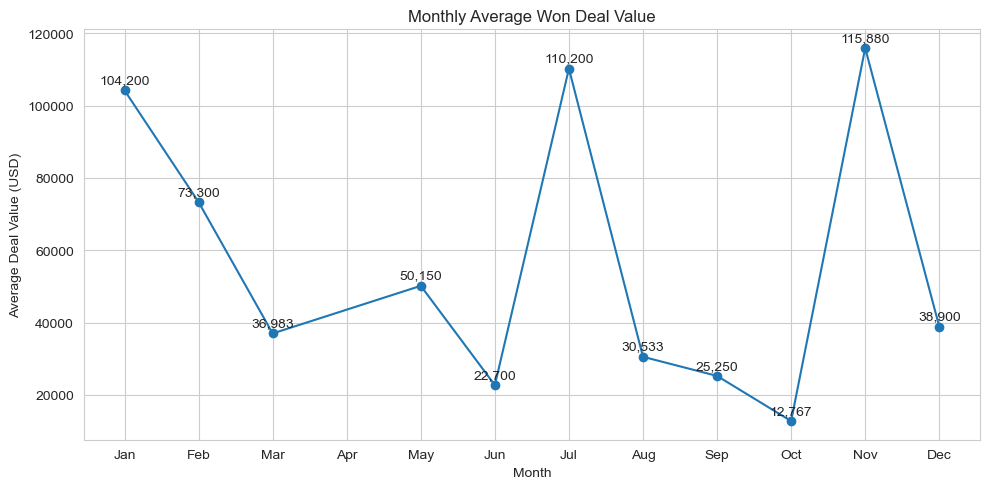

In [84]:
# =========================================================
# MONTHLY DEAL SIZE VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_deal_value.index,
    monthly_deal_value["avg_won_deal_value"],
    marker="o"
)

for month, value in zip(
    monthly_deal_value.index,
    monthly_deal_value["avg_won_deal_value"]
):
    plt.text(
        month,
        value + 2000,
        f"{value:,.0f}",
        ha="center"
    )

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.xticks(
    ticks=range(1, 13),
    labels=month_names,
    rotation= 0 
)

plt.title("Monthly Average Won Deal Value")
plt.xlabel("Month")
plt.ylabel("Average Deal Value (USD)")
plt.grid(True)

plt.tight_layout()
plt.show()

## Monthly Deal Size Findings

The analysis of average deal size reveals substantial seasonal variation in realized revenue per deal.

- **November** recorded the highest average won deal value at approximately **$115,880**, making it the strongest month for high-value deal closures.
- **January** and **July** also showed exceptionally high deal values, both exceeding **$100,000** per closed deal.
- **October** recorded the lowest average deal value at only **$12,767**, indicating significantly smaller deal closures during that period.
- No deals were closed in **April**, which aligns with the previously observed **0% conversion rate** for that month.

Overall, deal size exhibits the strongest seasonal variation among all metrics analyzed, suggesting that seasonality impacts not only conversion efficiency but also the financial value of closed deals.

## Seasonality Analysis Summary

Seasonality affects different business metrics in different ways.

- **Lead volume** remained relatively stable throughout the year, showing only mild fluctuations.
- **Conversion rate** showed stronger seasonal variation, with significant differences between high-performing and weak months.
- **Average deal size** exhibited the strongest seasonality, with major fluctuations in revenue per closed deal.

These findings suggest that seasonality at Nexus Digital is driven less by lead generation volume and more by lead quality, sales effectiveness, and deal size.

============================================================

# Question 8 — Lost Deal Analysis

============================================================

In this section, we analyze the primary reasons deals are lost.

The objective is to identify recurring loss patterns and determine whether specific channels, sales reps, or company segments face different obstacles during the sales process.

## Overall Lost Deal Reasons

We begin by examining the overall distribution of lost deal reasons across all unsuccessful deals.

This helps identify the most common factors preventing deals from closing.

In [85]:
# =========================================================
# OVERALL LOST DEAL REASONS
# =========================================================

# Filter only lost deals
lost_df = df[df["status"] == "Lost"]

# Count each lost reason
lost_reasons = lost_df["lost_reason"].value_counts()

# Display results
lost_reasons

lost_reason
No Response    44
Competitor     38
Budget         29
Bad Fit        22
Timing         10
Name: count, dtype: int64

## Lost Reason Distribution Visualization

The following chart visualizes the frequency of each lost reason to highlight the most common causes of deal failure.

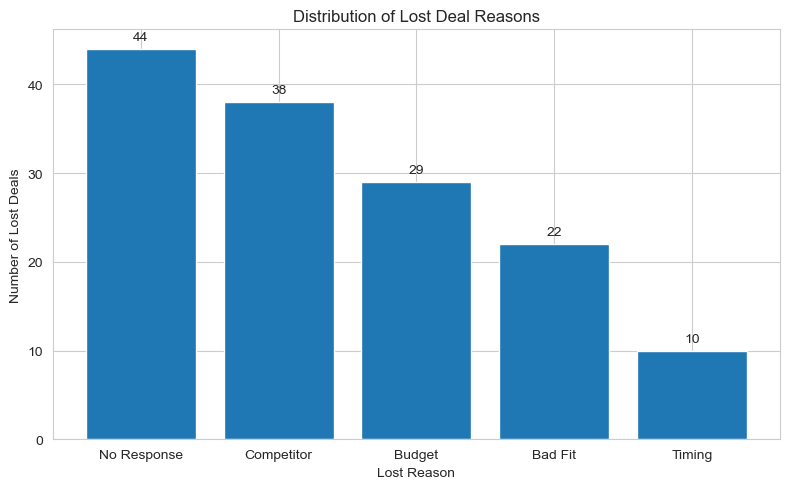

In [86]:
# =========================================================
# LOST REASON VISUALIZATION
# =========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    lost_reasons.index,
    lost_reasons.values
)

# Add labels above bars
for reason, count in zip(
    lost_reasons.index,
    lost_reasons.values
):
    plt.text(
        reason,
        count + 1,
        str(count),
        ha="center"
    )

plt.title("Distribution of Lost Deal Reasons")
plt.xlabel("Lost Reason")
plt.ylabel("Number of Lost Deals")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Lost Reasons by Acquisition Channel

Next, we examine whether different acquisition channels lose deals for different reasons.

This helps identify channel-specific weaknesses in the sales funnel.

In [87]:
# =========================================================
# LOST REASONS BY CHANNEL
# =========================================================

# Create cross-tabulation between lead source and lost reason
channel_lost = pd.crosstab(
    lost_df["lead_source"],
    lost_df["lost_reason"]
)

# Display results
channel_lost

lost_reason,Bad Fit,Budget,Competitor,No Response,Timing
lead_source,,,,,
Cold Email,1,2,5,17,0
Content Download,1,2,4,2,0
Google Ads,6,5,3,4,3
LinkedIn Ads,4,6,9,9,2
Organic Search,3,6,8,4,3
Referral,1,2,0,2,0
Trade Show,1,2,5,2,1
Webinar,5,4,4,4,1


## Lost Reason Distribution by Channel

Raw counts may be misleading because channels generate different numbers of lost deals.

To enable fair comparison, lost reasons are normalized into percentages within each acquisition channel.

In [88]:
# =========================================================
# LOST REASON PERCENTAGES BY CHANNEL
# =========================================================

# Convert raw counts into row percentages
channel_lost_pct = (
    channel_lost.div(
        channel_lost.sum(axis=1),
        axis=0
    ) * 100
)

# Round values
channel_lost_pct = channel_lost_pct.round(2)

# Display results
channel_lost_pct

lost_reason,Bad Fit,Budget,Competitor,No Response,Timing
lead_source,,,,,
Cold Email,4.00,8.00,20.00,68.00,0.00
Content Download,11.11,22.22,44.44,22.22,0.00
Google Ads,28.57,23.81,14.29,19.05,14.29
LinkedIn Ads,13.33,20.00,30.00,30.00,6.67
Organic Search,12.50,25.00,33.33,16.67,12.50
Referral,20.00,40.00,0.00,40.00,0.00
Trade Show,9.09,18.18,45.45,18.18,9.09
Webinar,27.78,22.22,22.22,22.22,5.56


## Lost Reasons by Sales Representative

Next, we examine whether sales representatives lose deals for different reasons.

This helps identify whether certain reps struggle with specific sales challenges such as pricing objections, competition, or lead engagement.

In [89]:
# =========================================================
# LOST REASONS BY SALES REP
# =========================================================

rep_lost = pd.crosstab(
    lost_df["assigned_rep"],
    lost_df["lost_reason"]
)

rep_lost

lost_reason,Bad Fit,Budget,Competitor,No Response,Timing
assigned_rep,,,,,
David Park,4,3,6,9,1
Emily Rodriguez,4,7,5,9,2
James Morrison,3,5,7,6,2
Marcus Webb,5,1,10,8,1
Olivia Foster,4,9,6,6,2
Sarah Chen,2,4,4,6,2


## Lost Reason Distribution by Sales Representative

Because sales representatives handle different numbers of leads, raw loss counts may be misleading.

Lost reasons are therefore normalized into percentages to compare each representative’s loss profile more fairly.

In [90]:
# =========================================================
# LOST REASON PERCENTAGES BY SALES REP
# =========================================================

rep_lost_pct = (
    rep_lost.div(
        rep_lost.sum(axis=1),
        axis=0
    ) * 100
)

rep_lost_pct = rep_lost_pct.round(2)

rep_lost_pct

lost_reason,Bad Fit,Budget,Competitor,No Response,Timing
assigned_rep,,,,,
David Park,17.39,13.04,26.09,39.13,4.35
Emily Rodriguez,14.81,25.93,18.52,33.33,7.41
James Morrison,13.04,21.74,30.43,26.09,8.70
Marcus Webb,20.00,4.00,40.00,32.00,4.00
Olivia Foster,14.81,33.33,22.22,22.22,7.41
Sarah Chen,11.11,22.22,22.22,33.33,11.11


## Lost Deal Findings by Sales Representative

Lost reasons vary significantly across sales representatives, suggesting that different reps face different sales challenges.

- **Marcus Webb** loses **40%** of deals to competitors but only **4%** due to budget constraints, indicating he likely handles larger, more competitive enterprise deals.
- **Olivia Foster** shows the highest budget-related loss rate (**33.33%**), suggesting greater exposure to price-sensitive customers.
- **David Park** has the highest rate of **No Response** losses (**39.13%**), indicating customer disengagement as a major challenge.
- **Sarah Chen** displays the most balanced loss distribution, with no single dominant failure reason.

Overall, these findings suggest that coaching and performance improvement strategies should be tailored to each representative’s specific loss patterns rather than applied uniformly.

## Lost Reasons by Company Size

Finally, we analyze whether companies of different sizes tend to lose deals for different reasons.

This helps determine whether sales obstacles vary across customer segments.

In [91]:
# =========================================================
# LOST REASONS BY COMPANY SIZE
# =========================================================

company_lost = pd.crosstab(
    lost_df["company_size"],
    lost_df["lost_reason"]
)

company_lost

lost_reason,Bad Fit,Budget,Competitor,No Response,Timing
company_size,,,,,
Enterprise (1000+),2,2,6,7,2
Large (201-1000),3,7,10,9,2
Medium (51-200),9,10,13,19,5
Small (1-50),8,10,9,9,1


## Lost Reason Distribution by Company Size

Raw loss counts may be misleading because different company segments contain different numbers of opportunities.

To compare company segments fairly, lost reasons are normalized into percentages within each company size category.

In [92]:
# =========================================================
# LOST REASON PERCENTAGES BY COMPANY SIZE
# =========================================================

company_lost_pct = (
    company_lost.div(
        company_lost.sum(axis=1),
        axis=0
    ) * 100
)

company_lost_pct = company_lost_pct.round(2)

company_lost_pct

lost_reason,Bad Fit,Budget,Competitor,No Response,Timing
company_size,,,,,
Enterprise (1000+),10.53,10.53,31.58,36.84,10.53
Large (201-1000),9.68,22.58,32.26,29.03,6.45
Medium (51-200),16.07,17.86,23.21,33.93,8.93
Small (1-50),21.62,27.03,24.32,24.32,2.70


## Lost Deal Findings by Company Size

Lost reasons vary meaningfully across company segments.

- **Small companies** show the highest budget-related loss rate (**27.03%**), indicating strong price sensitivity.
- **Enterprise accounts** show the lowest budget-related loss rate (**10.53%**) but higher losses due to **competition (31.58%)** and **No Response (36.84%)**.
- **Medium-sized companies** exhibit the highest no-response rate (**33.93%**), suggesting customer disengagement is a major challenge.
- As company size increases, budget becomes less important while competitive pressure becomes more significant.

These findings suggest that sales strategies should be adapted to company size, with pricing emphasis for smaller accounts and competitive differentiation for larger enterprise deals.

## Lost Deal Analysis Summary

Lost deals at Nexus Digital are driven by multiple factors, with meaningful variation across channels, sales representatives, and company segments.

- **No Response** is the most common overall loss reason, indicating customer disengagement as a major challenge.
- Different acquisition channels show distinct weaknesses, such as high ghosting in **Cold Email** and strong competitive pressure in **Trade Show** leads.
- Sales representatives exhibit different loss profiles, suggesting coaching should be personalized rather than standardized.
- Company size strongly influences loss patterns: smaller companies are more budget-sensitive, while larger companies are more affected by competition and long decision cycles.

Overall, lost deal patterns are highly segment-specific, indicating that a single sales strategy is unlikely to optimize performance across all customer groups.

============================================================

# Question 9 — Industry Segmentation

============================================================

In this section, we analyze performance across industries.

The goal is to identify which industries convert most effectively, which generate the highest deal values, and whether specific channel-industry combinations perform particularly well or poorly.

## Industry Conversion Rate

We begin by comparing conversion rates across industries to determine which market segments generate the highest sales success.

In [93]:
# =========================================================
# INDUSTRY CONVERSION RATE
# =========================================================

industry_conversion = df.groupby("industry").agg(

    # Count total leads in each industry
    total_leads=("lead_id", "count"),

    # Count won deals
    won_leads=(
        "status",
        lambda x: (x == "Won").sum()
    )
)

# Calculate conversion rate
industry_conversion["conversion_rate"] = (
    industry_conversion["won_leads"] /
    industry_conversion["total_leads"]
) * 100

# Round values
industry_conversion["conversion_rate"] = (
    industry_conversion["conversion_rate"].round(2)
)

industry_conversion

,total_leads,won_leads,conversion_rate
industry,,,
Education,50,2,4.00
Finance,72,2,2.78
Healthcare,98,5,5.10
Manufacturing,63,7,11.11
Real Estate,48,2,4.17
Retail,108,8,7.41
Technology,161,10,6.21


## Industry Conversion Rate Visualization

The following chart compares conversion rates across industries to highlight the most and least efficient market segments.

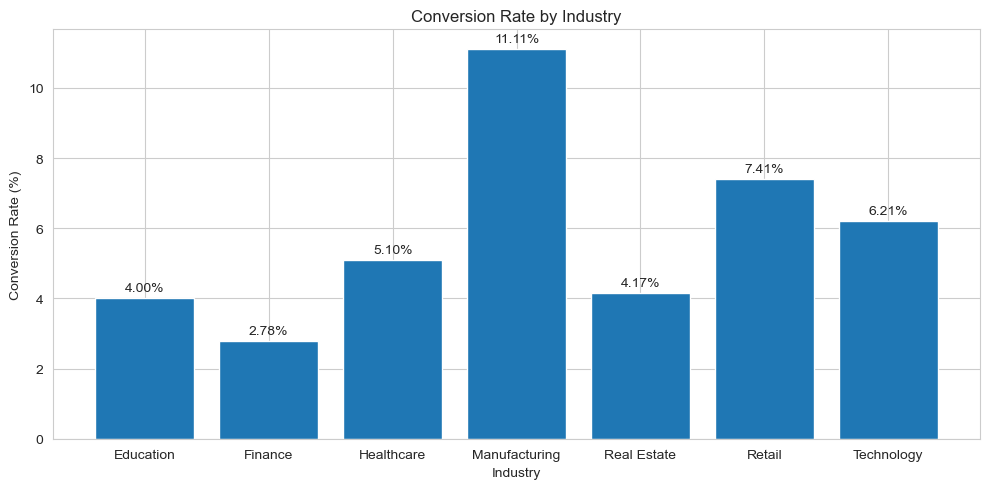

In [94]:
# =========================================================
# INDUSTRY CONVERSION VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 5))

plt.bar(
    industry_conversion.index,
    industry_conversion["conversion_rate"]
)

# Add labels above bars
for industry, rate in zip(
    industry_conversion.index,
    industry_conversion["conversion_rate"]
):
    plt.text(
        industry,
        rate + 0.2,
        f"{rate:.2f}%",
        ha="center"
    )

plt.title("Conversion Rate by Industry")
plt.xlabel("Industry")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Industry Conversion Findings

Conversion performance varies significantly across industries.

- **Manufacturing** achieved the highest conversion rate at **11.11%**, indicating strong lead quality and sales efficiency.
- **Finance** recorded the lowest conversion rate at **2.78%**, suggesting significant sales friction within that segment.
- **Technology** generated the highest lead volume but only moderate conversion efficiency.
- These findings suggest that industry segmentation plays a meaningful role in sales performance and conversion outcomes.

## Industry Deal Value Analysis

Next, we examine average realized deal value across industries to identify which market segments generate the highest revenue per closed deal.

Only closed-won deals are included to ensure revenue reflects realized sales.

In [95]:
# =========================================================
# INDUSTRY AVERAGE WON DEAL VALUE
# =========================================================

# Recreate won deals dataframe
won_df = df[df["status"] == "Won"]

# Group won deals by industry
industry_deal_value = won_df.groupby("industry").agg(

    # Calculate average realized deal value
    avg_won_deal_value=("deal_value", "mean")
)

# Round values
industry_deal_value["avg_won_deal_value"] = (
    industry_deal_value["avg_won_deal_value"].round(2)
)

# Display results
industry_deal_value

,avg_won_deal_value
industry,
Education,"15,300.00"
Finance,"63,450.00"
Healthcare,"28,300.00"
Manufacturing,"79,014.29"
Real Estate,"85,050.00"
Retail,"93,687.50"
Technology,"35,130.00"


## Industry Deal Value Visualization

The following chart compares average realized deal value across industries to identify the highest-value market segments.

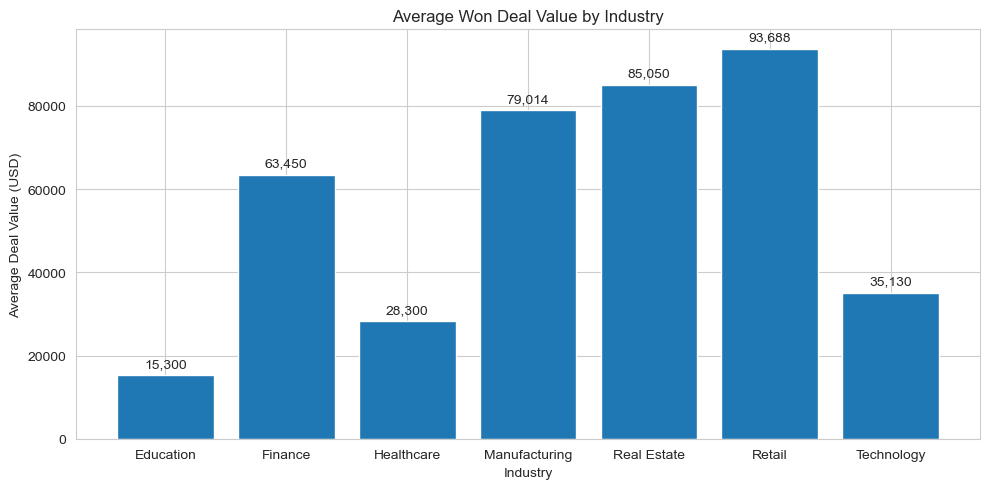

In [96]:
# =========================================================
# INDUSTRY DEAL VALUE VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 5))

plt.bar(
    industry_deal_value.index,
    industry_deal_value["avg_won_deal_value"]
)

# Add labels above bars
for industry, value in zip(
    industry_deal_value.index,
    industry_deal_value["avg_won_deal_value"]
):
    plt.text(
        industry,
        value + 2000,
        f"{value:,.0f}",
        ha="center"
    )

plt.title("Average Won Deal Value by Industry")
plt.xlabel("Industry")
plt.ylabel("Average Deal Value (USD)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Industry Deal Value Findings

Average deal value varies significantly across industries.

- **Retail** generated the highest average deal value at approximately **$93,688** per closed deal.
- **Manufacturing** also performed strongly, combining high deal values with the strongest conversion rate.
- **Finance** showed low conversion but relatively high deal values, suggesting a high-risk, high-reward segment.
- **Education** produced the lowest average deal value, making it the least attractive segment in revenue terms.

These findings suggest that industry attractiveness depends not only on conversion efficiency but also on the revenue potential of each closed deal.

## Channel–Industry Combination Analysis

Finally, we examine whether specific acquisition channels perform better or worse within certain industries.

To avoid misleading conclusions from very small samples, only channel–industry combinations with at least 5 leads are included in the analysis.

In [97]:
# =========================================================
# CHANNEL + INDUSTRY PERFORMANCE
# =========================================================

channel_industry = df.groupby(
    ["lead_source", "industry"]
).agg(

    # Count total leads
    total_leads=("lead_id", "count"),

    # Count won deals
    won_leads=(
        "status",
        lambda x: (x == "Won").sum()
    )
)

# Keep only combinations with at least 5 leads
channel_industry = channel_industry[
    channel_industry["total_leads"] >= 5
]

# Calculate conversion rate
channel_industry["conversion_rate"] = (
    channel_industry["won_leads"] /
    channel_industry["total_leads"]
) * 100

channel_industry["conversion_rate"] = (
    channel_industry["conversion_rate"].round(2)
)

channel_industry

total_leads  won_leads  conversion_rate
lead_source      industry                                              
Cold Email       Education                7          0             0.00
                 Finance                  8          0             0.00
                 Healthcare              14          0             0.00
                 Manufacturing           11          1             9.09
                 Real Estate              9          1            11.11
                 Retail                  17          3            17.65
                 Technology              23          0             0.00
Content Download Education                6          0             0.00
                 Finance                  6          0             0.00
                 Healthcare              12          1             8.33
                 Manufacturing            6          1            16.67
                 Retail                   7          0             0.00
                 Technology              14          1             7.14
Google Ads       Education                5          1            20.00
                 Finance                 18          0             0.00
                 Healthcare              12          0             0.00
                 Manufacturing            5          1            20.00
                 Real Estate             14          1             7.14
                 Retail                  17          0             0.00
                 Technology              37          3             8.11
LinkedIn Ads     Education                7          0             0.00
                 Finance                 12          0             0.00
                 Healthcare              17          1             5.88
                 Manufacturing           11          0             0.00
                 Real Estate              6          0             0.00
                 Retail                  21          0             0.00
                 Technology              27          0             0.00
Organic Search   Education               10          1            10.00
                 Finance                 10          0             0.00
                 Healthcare              17          1             5.88
                 Manufacturing            6          0             0.00
                 Real Estate              6          0             0.00
                 Retail                  11          1             9.09
                 Technology              19          1             5.26
Referral         Finance                  6          1            16.67
                 Healthcare               7          1            14.29
                 Manufacturing            5          2            40.00
                 Retail                  11          1             9.09
                 Technology              11          3            27.27
Trade Show       Education                5          0             0.00
                 Finance                  6          0             0.00
                 Healthcare               5          0             0.00
                 Manufacturing           10          1            10.00
                 Retail                   9          2            22.22
                 Technology               9          1            11.11
Webinar          Education                7          0             0.00
                 Finance                  6          1            16.67
                 Healthcare              14          1             7.14
                 Manufacturing            9          1            11.11
                 Real Estate              9          0             0.00
                 Retail                  15          1             6.67
                 Technology              21          1             4.76

## Channel–Industry Combination Findings

Channel effectiveness varies significantly across industries, indicating that acquisition performance is highly segment-dependent.

- **Referral + Technology** showed one of the strongest reliable combinations, achieving a **27.27% conversion rate**, suggesting referral-based trust is highly valuable in the technology sector.
- **Trade Show + Retail** also performed strongly with a **22.22% conversion rate**, indicating strong in-person sales effectiveness for retail buyers.
- **Cold Email + Retail** performed surprisingly well (**17.65%**), despite Cold Email performing poorly overall.
- Several combinations performed particularly poorly, including **LinkedIn Ads + Technology (0%)**, **LinkedIn Ads + Retail (0%)**, and **Cold Email + Technology (0%)**, despite meaningful lead volume.

These findings indicate that channel effectiveness is highly industry-specific, suggesting acquisition strategies should be tailored to individual market segments rather than applied uniformly across all industries.

============================================================

# Question 10 — Company Size Analysis

============================================================

In this section, we analyze how company size affects conversion rate, deal value, and sales cycle duration.

We also examine whether certain sales representatives disproportionately manage specific company segments.

## Company Size and Conversion Rate

We begin by analyzing conversion performance across company size segments to determine whether larger organizations convert more efficiently than smaller ones.

In [98]:
# =========================================================
# COMPANY SIZE CONVERSION RATE
# =========================================================

company_conversion = df.groupby("company_size").agg(

    # Count total leads
    total_leads=("lead_id", "count"),

    # Count won deals
    won_leads=(
        "status",
        lambda x: (x == "Won").sum()
    )
)

# Calculate conversion rate
company_conversion["conversion_rate"] = (
    company_conversion["won_leads"] /
    company_conversion["total_leads"]
) * 100

# Round values
company_conversion["conversion_rate"] = (
    company_conversion["conversion_rate"].round(2)
)

company_conversion

,total_leads,won_leads,conversion_rate
company_size,,,
Enterprise (1000+),99,7,7.07
Large (201-1000),123,5,4.07
Medium (51-200),211,15,7.11
Small (1-50),167,9,5.39


## Company Size Conversion Visualization

The following chart compares conversion rates across company size segments.

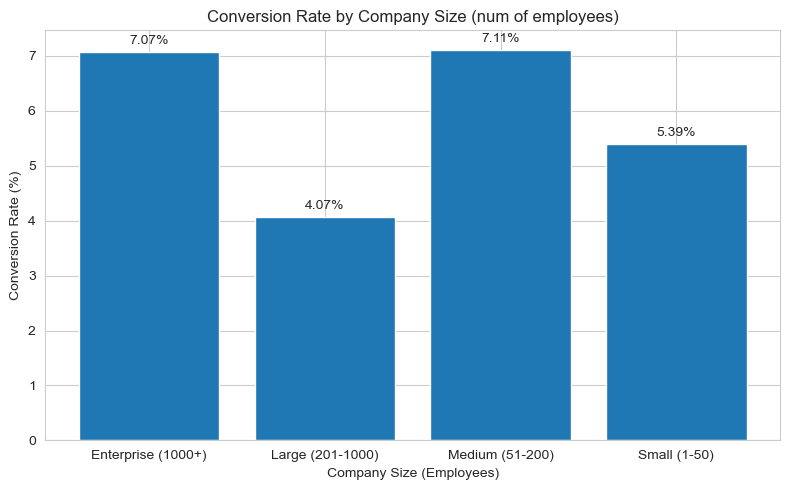

In [99]:
# =========================================================
# COMPANY SIZE CONVERSION VISUALIZATION
# =========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    company_conversion.index,
    company_conversion["conversion_rate"]
)

for size, rate in zip(
    company_conversion.index,
    company_conversion["conversion_rate"]
):
    plt.text(
        size,
        rate + 0.15,
        f"{rate:.2f}%",
        ha="center"
    )

plt.title("Conversion Rate by Company Size (num of employees)")
plt.xlabel("Company Size (Employees)")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Company Size Conversion Findings

Conversion performance varies across company size segments and does not increase linearly with company size.

- **Medium-sized companies** achieved the highest conversion rate at **7.11%**.
- **Enterprise accounts** followed closely at **7.07%**, showing strong conversion despite complex buying processes.
- **Large companies** recorded the lowest conversion rate at **4.07%**, indicating greater sales friction within this segment.
- **Small companies** converted at a moderate rate of **5.39%**, likely influenced by higher budget sensitivity.

These findings suggest that medium-sized companies may offer the most attractive balance between deal accessibility and purchasing power.

## Company Size and Deal Value

Next, we analyze whether larger companies generate higher average deal values.

Only closed-won deals are included to ensure revenue reflects actual realized sales.

In [100]:
# =========================================================
# COMPANY SIZE VS DEAL VALUE
# =========================================================

# Recreate won deals dataframe
won_df = df[df["status"] == "Won"]

# Group won deals by company size
company_deal_value = won_df.groupby("company_size").agg(

    # Calculate average realized deal value
    avg_won_deal_value=("deal_value", "mean")
)

# Round values
company_deal_value["avg_won_deal_value"] = (
    company_deal_value["avg_won_deal_value"].round(2)
)

# Display results
company_deal_value

,avg_won_deal_value
company_size,
Enterprise (1000+),"172,471.43"
Large (201-1000),"77,620.00"
Medium (51-200),"30,873.33"
Small (1-50),"7,166.67"


## Company Size Deal Value Visualization

The following chart compares average realized deal value across company size segments.

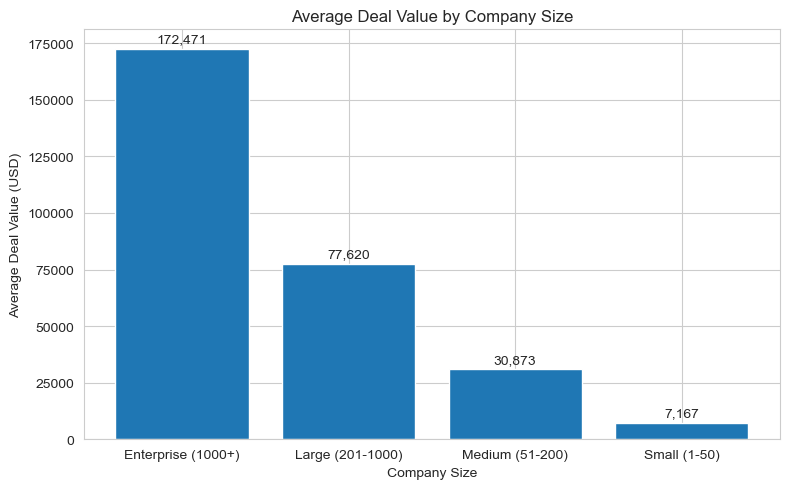

In [101]:
# =========================================================
# COMPANY SIZE DEAL VALUE VISUALIZATION
# =========================================================

# Create chart canvas
plt.figure(figsize=(8, 5))

# Create bar chart:
# X-axis = company size categories
# Y-axis = average won deal value
plt.bar(
    company_deal_value.index,
    company_deal_value["avg_won_deal_value"]
)

# Add value labels above each bar
for size, value in zip(
    company_deal_value.index,
    company_deal_value["avg_won_deal_value"]
):
    plt.text(
        size,          # X position
        value + 3000,  # Slightly above bar
        f"{value:,.0f}",  # Format number with commas
        ha="center"    # Center text horizontally
    )

# Add chart title
plt.title("Average Deal Value by Company Size")

# Label X-axis
plt.xlabel("Company Size")

# Label Y-axis
plt.ylabel("Average Deal Value (USD)")

# Rotate labels for readability
plt.xticks(rotation=0)

# Adjust spacing automatically
plt.tight_layout()

# Display chart
plt.show()

## Company Size Deal Value Findings

Average deal value increases significantly with company size.

- **Enterprise accounts** generated the highest average deal value at approximately **$172,471**.
- **Large companies** averaged approximately **$77,620** per closed deal.
- **Medium companies** generated moderate deal values at roughly **$30,873**.
- **Small companies** produced the lowest average deal values at approximately **$7,167**.

These findings indicate a strong positive relationship between company size and revenue potential, with larger organizations generating substantially larger contracts.

## Company Size and Sales Cycle Length

Next, we analyze whether company size affects sales cycle duration.

Sales cycle length is calculated as the number of days between lead creation and the last recorded sales activity.

In [102]:
# =========================================================
# SALES CYCLE LENGTH BY COMPANY SIZE
# =========================================================

# Date columns were parsed as datetime at load (dayfirst=True)

# Calculate sales cycle length in days
df["sales_cycle_days"] = (
    df["last_activity_date"] - df["created_date"]
).dt.days

# Group by company size and calculate average cycle length
company_cycle = df.groupby("company_size").agg(

    # Average number of days in sales cycle
    avg_sales_cycle=("sales_cycle_days", "mean")
)

# Round values
company_cycle["avg_sales_cycle"] = (
    company_cycle["avg_sales_cycle"].round(2)
)

# Display results
company_cycle

,avg_sales_cycle
company_size,
Enterprise (1000+),74.26
Large (201-1000),59.39
Medium (51-200),57.12
Small (1-50),58.16


## Company Size Sales Cycle Visualization

The following chart compares average sales cycle duration across company size segments to examine whether larger organizations require longer sales processes.

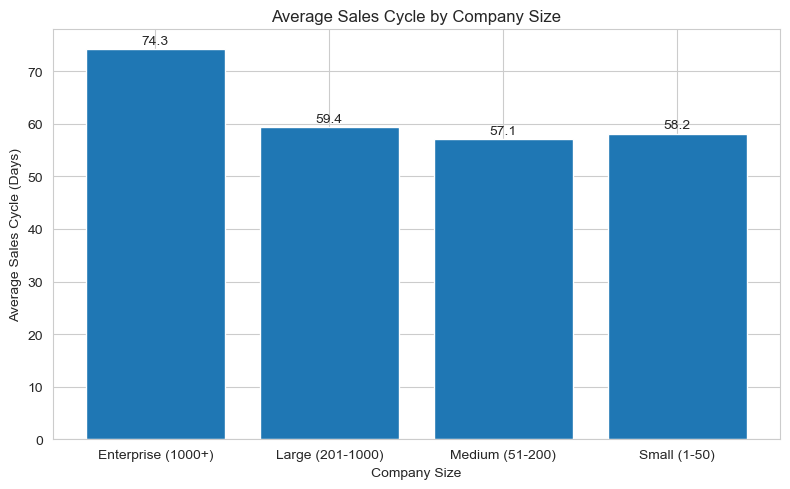

In [103]:
# =========================================================
# COMPANY SIZE SALES CYCLE VISUALIZATION
# =========================================================

# Create chart canvas
plt.figure(figsize=(8, 5))

# Create bar chart
plt.bar(
    company_cycle.index,
    company_cycle["avg_sales_cycle"]
)

# Add labels above each bar
for size, days in zip(
    company_cycle.index,
    company_cycle["avg_sales_cycle"]
):
    plt.text(
        size,
        days + 1,
        f"{days:.1f}",
        ha="center"
    )

# Add chart title
plt.title("Average Sales Cycle by Company Size")

# Label x-axis
plt.xlabel("Company Size")

# Label y-axis
plt.ylabel("Average Sales Cycle (Days)")

# Rotate labels
plt.xticks(rotation=0)

# Adjust spacing
plt.tight_layout()

# Display chart
plt.show()

## Company Size Sales Cycle Findings

Sales cycle duration generally increases with company size.

- **Enterprise accounts** had the longest average sales cycle at **74.26 days**, indicating longer decision-making and approval processes.
- **Large companies** averaged **59.39 days**.
- **Small** and **Medium companies** showed similar sales cycle durations at approximately **57–58 days**.
- Enterprise deals therefore require significantly more time to close compared with smaller customer segments.

These findings suggest that larger organizations involve more stakeholders and more complex purchasing procedures, resulting in longer sales cycles.

## Sales Representative Distribution by Company Size

Finally, we examine whether certain sales representatives disproportionately manage specific company size segments.

This helps determine whether performance differences between reps may partly reflect account allocation rather than individual effectiveness.

In [104]:
# =========================================================
# REP DISTRIBUTION BY COMPANY SIZE
# =========================================================

# Create cross-tab between reps and company size
rep_company = pd.crosstab(
    df["assigned_rep"],
    df["company_size"]
)

# Display results
rep_company

company_size,Enterprise (1000+),Large (201-1000),Medium (51-200),Small (1-50)
assigned_rep,,,,
David Park,7,19,34,25
Emily Rodriguez,8,20,43,37
James Morrison,7,23,41,26
Marcus Webb,59,15,19,23
Olivia Foster,9,20,36,28
Sarah Chen,9,26,38,28


## Sales Representative Distribution by Company Size

Sales representative account allocation is largely balanced across most team members, with one notable exception.

- **Marcus Webb** handles a disproportionately large number of **Enterprise accounts (59)**, while all other representatives manage only **7–9 enterprise accounts**.
- The remaining sales representatives show relatively balanced account distribution across company size segments.
- **Medium-sized companies** represent the largest segment for most representatives.

These findings suggest that performance differences between representatives may partly reflect account allocation rather than individual effectiveness. In particular, Marcus Webb’s lower conversion rate may be influenced by the complexity of enterprise-level sales rather than poor sales performance.

# =========================================================
# PART 1 SUMMARY
# =========================================================

Part 1 provided a comprehensive exploratory analysis of Nexus Digital’s sales pipeline across channels, campaigns, sales representatives, industries, and customer segments.

Key findings include:

- Sales performance varies significantly across acquisition channels, industries, and company sizes, indicating that sales success is highly segment-dependent.
- Faster response times are associated with higher conversion rates, highlighting the importance of rapid lead engagement.
- Lost deal analysis showed that **No Response** is the most common reason for failure, making customer disengagement a major challenge.
- Larger companies generate significantly higher deal values and longer sales cycles, while medium-sized companies achieved the strongest conversion rates.

Overall, the analysis suggests that targeted, segment-specific sales strategies are likely to outperform a uniform sales approach.

# =========================================================
# PART 2 — KPI DEFINITION
# =========================================================

Based on the exploratory analysis in Part 1, the following KPIs are recommended for ongoing performance monitoring at Nexus Digital.

These KPIs were selected to track sales efficiency, revenue generation, lead quality, and customer engagement across the sales funnel.

---
## KPI 1 — Lead-to-Win Rate
**Formula:**  
Lead-to-Win Rate = (Won Leads / Total Leads) × 100

**Current Value:**  
8.33% (50 won deals out of 600 total leads)

**Proposed Target (Next Quarter):**  
10–12%

**Target Justification:**  
The current win rate is relatively low, indicating room for improvement in lead qualification and sales execution. A target of 10–12% represents a realistic improvement of approximately 20–40% over current performance, achievable through better response speed and improved lead prioritization.

**Business Rationale:**  
Lead-to-Win Rate is the primary KPI for evaluating overall sales funnel effectiveness. It measures how efficiently leads are converted into paying customers and directly impacts revenue generation.

**Responsible Owner:**  
Sales Team + Revenue Operations

---
## KPI 2 — Average First Response Time

**Formula:**  
Average First Response Time = Average(hours from lead creation to first sales outreach)

**Current Value:**  
Approximately 17–18 hours

**Proposed Target (Next Quarter):**  
Less than 8 hours

**Target Justification:**  
Part 1 analysis showed a clear relationship between response speed and conversion performance. Leads contacted within the first 8 hours demonstrated significantly higher conversion rates, while delayed follow-up increased the likelihood of lead drop-off. Reducing average response time below 8 hours should improve lead engagement and conversion.

**Business Rationale:**  
Response time is a leading indicator of sales success. Faster engagement reduces the chance of leads going cold and improves the probability of progressing leads through the funnel.

**Responsible Owner:**  
Sales Team

---
## KPI 3 — No Response Loss Rate

**Formula:**  
No Response Loss Rate = (Lost Deals Due to No Response / Total Lost Deals) × 100

**Current Value:**  
30.77% (44 out of 143 lost deals)

**Proposed Target (Next Quarter):**  
Below 20%

**Target Justification:**  
Part 1 analysis identified No Response as the most common lost deal reason, accounting for nearly one-third of all lost opportunities. Reducing this metric below 20% would represent a meaningful improvement in lead engagement and follow-up effectiveness.

**Business Rationale:**  
This KPI measures preventable funnel leakage caused by poor engagement or delayed follow-up. A high No Response rate indicates missed sales opportunities and inefficient lead nurturing processes.

**Responsible Owner:**  
Sales Team + Marketing Team

---
## KPI 4 — Average Won Deal Value

**Formula:**  
Average Won Deal Value = Average(deal_value for Won deals)

**Current Value:**  
$58,972 (average value across all closed-won deals)

**Proposed Target (Next Quarter):**  
Increase by 10–15%

**Target Justification:**  
Part 1 analysis showed substantial variation in deal values across industries and company sizes, with Enterprise accounts generating significantly higher revenue than smaller segments. A 10–15% increase is realistic through improved focus on high-value segments such as Enterprise and Manufacturing.

**Business Rationale:**  
This KPI measures revenue quality rather than sales volume alone. Increasing average deal value improves revenue efficiency and maximizes the return on sales and marketing efforts.

**Responsible Owner:**  
Sales Team + Finance

In [105]:
df["sales_cycle_days"].mean()

np.float64(60.70333333333333)

---
## KPI 5 — Sales Cycle Length

**Formula:**  
Sales Cycle Length = Average(last_activity_date − created_date)

**Current Value:**  
60.7 days

**Proposed Target (Next Quarter):**  
Reduce by 10–15%

**Target Justification:**  
Part 1 analysis showed that Enterprise accounts have significantly longer sales cycles than other customer segments, increasing the overall average cycle length. A 10–15% reduction is achievable through better pipeline management, faster follow-ups, and improved qualification of high-potential leads.

**Business Rationale:**  
This KPI measures how efficiently leads progress through the sales funnel. Shorter sales cycles improve cash flow, accelerate revenue realization, and increase sales team productivity.

**Responsible Owner:**  
Sales Team + Revenue Operations

---
## KPI 6 — Revenue per Lead

**Formula:**  
Revenue per Lead = Total Won Revenue / Total Leads

**Current Value:**  
$4,914 per lead

**Proposed Target (Next Quarter):**  
Increase by 15%

**Target Justification:**  
Revenue per lead is influenced by both conversion rate and deal size. Since Part 1 revealed opportunities to improve response speed, lead prioritization, and focus on high-value customer segments, a 15% increase is considered achievable.

**Business Rationale:**  
This KPI provides a holistic view of sales efficiency by combining lead quality, conversion performance, and revenue generation into a single metric.

**Responsible Owner:**  
Marketing Team + Sales Team

---
## KPI 7 — Rep Conversion Rate

**Formula:**  
Rep Conversion Rate = (Won Leads per Rep / Total Leads per Rep) × 100

**Current Value:**  
Ranges from 2.35% to 11.88% across sales representatives

**Proposed Target (Next Quarter):**  
Improve team-wide average by 2–3 percentage points

**Target Justification:**  
Part 1 revealed substantial variation in conversion rates across sales representatives. Some performance differences are explained by account allocation, but narrowing this gap through coaching and best-practice sharing remains achievable.

**Business Rationale:**  
This KPI helps identify high-performing representatives and uncover coaching opportunities for underperforming team members.

**Responsible Owner:**  
Sales Managers

---
## KPI 8 — High-Score Lead Conversion Rate

**Formula:**  
High-Score Lead Conversion Rate = (Won High-Score Leads / Total High-Score Leads) × 100

**Current Value:**  
7.59%

**Proposed Target (Next Quarter):**  
Above 10%

**Target Justification:**  
High-score leads should convert better than average if the lead scoring model is effective. Increasing this metric above 10% would indicate better alignment between scoring logic and actual sales outcomes.

**Business Rationale:**  
This KPI evaluates the predictive quality of the lead scoring model and ensures that sales resources are focused on the highest-value opportunities.

**Responsible Owner:**  
Revenue Operations

## KPI Summary Table

| KPI | Current Value | Target | Owner | Why It Matters |
|---|---:|---|---|---|
| Lead-to-Win Rate | 8.33% | 10–12% | Sales + RevOps | Measures overall funnel effectiveness |
| Avg First Response Time | 17–18 hrs | < 8 hrs | Sales | Faster outreach improves conversion |
| No Response Loss Rate | 30.8% | < 20% | Sales + Marketing | Largest source of preventable losses |
| Avg Won Deal Value | $58,972 | +10–15% | Sales + Finance | Tracks revenue quality |
| Sales Cycle Length | 60.7 days | -10–15% | Sales + RevOps | Shorter cycles improve cash flow |
| Revenue per Lead | $4,914 | +15% | Marketing + Sales | Measures acquisition efficiency |
| Rep Conversion Rate | 2.35%–11.88% | +2–3 pts | Sales Managers | Identifies coaching opportunities |
| High-Score Lead Conversion | 7.59% | > 10% | RevOps | Validates lead scoring model |

## Part 2 Complete

The KPI framework above provides Nexus Digital with a balanced set of leading and lagging indicators for monitoring sales performance, revenue efficiency, lead quality, and pipeline health.